In [1]:
import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
import pickle
import copy
import torch
import torch.serialization
import torch.nn as nn
import torch.nn.functional as F
import gpytorch
from gpytorch.models import ExactGP
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.mlls import ExactMarginalLogLikelihood
#from gp_pytorch_accelerated import GPModel
import warnings

warnings.filterwarnings('ignore')

from statistics import NormalDist

In [2]:
os.chdir(r"C:\Users\dweis\OneDrive\Documents\Career\Research Paper - FINAL")

In [3]:
def seed_everything(seed=42):

    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
_ND = NormalDist()


def _ensure_1d(a):
    a = np.asarray(a)
    return a.ravel()


def gaussian_log_predictive_density(y_true, y_mean, y_std, eps=1e-6):
    """Mean log N(y_true | y_mean, y_std^2)."""
    y_true = _ensure_1d(y_true)
    y_mean = _ensure_1d(y_mean)
    y_std = np.maximum(_ensure_1d(y_std), eps)
    z = (y_true - y_mean) / y_std
    return float(np.mean(-0.5 * np.log(2.0 * np.pi) - np.log(y_std) - 0.5 * z**2))


def gaussian_crps(y_true, y_mean, y_std, eps=1e-6):

    y_true = _ensure_1d(y_true)
    y_mean = _ensure_1d(y_mean)
    y_std = np.maximum(_ensure_1d(y_std), eps)
    z = (y_true - y_mean) / y_std
    phi = np.array([_ND.pdf(float(zi)) for zi in z])
    Phi = np.array([_ND.cdf(float(zi)) for zi in z])
    crps = y_std * (z * (2.0 * Phi - 1.0) + 2.0 * phi - 1.0 / np.sqrt(np.pi))
    return float(np.mean(crps))


def prediction_interval_coverage(y_true, y_mean, y_std, interval=0.95, eps=1e-6):

    y_true = _ensure_1d(y_true)
    y_mean = _ensure_1d(y_mean)
    y_std = np.maximum(_ensure_1d(y_std), eps)
    z = _ND.inv_cdf(0.5 + interval / 2.0)
    lower = y_mean - z * y_std
    upper = y_mean + z * y_std
    return float(np.mean((y_true >= lower) & (y_true <= upper)))

In [5]:
from src.data_loading import load_wind_data, extract_timeseries, split_timeperiods, normalise_timeseries
from src.vae_models import extract_vae_features, TimeSeriesVAE
from src.clustering import assign_test_clusters
from src.gp import create_cluster_forecasting_datasets, GPModel
from src.plotting import plot_cluster_predictions

In [ ]:
# Load target wind farm data
target_csv_path = r'....\Horns_Rev.csv'
target_df = load_wind_data(target_csv_path)

cols_to_drop = [c for c in target_df.columns if 'Scaled_Windspeed' in c or 'Power_of_' in c]
target_df = target_df.drop(columns=cols_to_drop)
target_df['farm_id'] = 'Kriegers'




# Load source farm metadata
with open(fr'...\Seed 84\all_combinations_2.0.pkl', 'rb') as f:
    all_combinations = pickle.load(f)

best_key = max(all_combinations, key=lambda k: all_combinations[k]['combined_score'])
optimal_config = all_combinations[best_key]
source_results = {'optimal_config': optimal_config}

Loading wind data from C:\Users\dweis\OneDrive\Documents\Career\Research Paper - FINAL\Data\Data\Horns_Rev.csv
  Loaded: 17520 hours
  Power range: 0.0 - 761.3 MW
  Power mean: 401.2 MW ± 280.8 MW


In [7]:
def transfer_learning_gp(target_df, source_results, data_fraction=0.1, 
                         gp_dir="results", plot_predictions_flag=False, random_state=42):
    
    print("="*80)
    print("GP TRANSFER LEARNING")
    print("="*80)
    
    # Extract source configuration
    optimal_config = source_results['optimal_config']
    n_clusters = optimal_config['k_clusters']
    time_period_hours = optimal_config['time_period_hours']
    source_vae = optimal_config['vae']
    source_train_latent = optimal_config['train_latent']
    source_train_labels = optimal_config['train_cluster_labels']
    
    # Get source scalers
    source_scalers_vae = optimal_config['scalers_vae']
    source_log_transforms_vae = optimal_config.get('log_transforms_vae', {})
    source_scalers_full = optimal_config['scalers_full']
    source_log_transforms_full = optimal_config.get('log_transforms_full', {})
    
    source_vae.eval()
    
    print(f"Configuration: {time_period_hours}h periods, {n_clusters} clusters")
    print(f"Target data: {data_fraction*100:.1f}% training")
    
    # DATA PREPARATION
    
    print("\nExtracting and Splitting...")
    timeseries_matrix_full_t, timeseries_matrix_vae_t, period_info_t = extract_timeseries(target_df, time_period_hours)
    
    test_ratio = 1.0 - data_fraction
    split_data_vae = split_timeperiods(timeseries_matrix_vae_t, period_info_t, test_ratio=test_ratio, random_state=random_state)
    
    train_indices = split_data_vae['train_indices']
    test_indices = split_data_vae['test_indices']
    train_period_info = split_data_vae['train_period_info']
    test_period_info = split_data_vae['test_period_info']
    
    train_timeseries_full_t = timeseries_matrix_full_t[train_indices]
    test_timeseries_full_t = timeseries_matrix_full_t[test_indices]
    train_timeseries_vae_t = split_data_vae['train_timeseries']
    test_timeseries_vae_t = split_data_vae['test_timeseries']
    
    # Normalisation
    vae_feature_names = ['Windspeed', 'fsr', 'u100', 'v100', 'wind_dir_sin', 'wind_dir_cos']
    train_normalised_vae_t = np.zeros_like(train_timeseries_vae_t, dtype=np.float32)
    test_normalised_vae_t = np.zeros_like(test_timeseries_vae_t, dtype=np.float32)

    for ch in range(train_timeseries_vae_t.shape[1]):
        channel_name = vae_feature_names[ch] if ch < len(vae_feature_names) else f'Channel_{ch}'
        if any(cyc in channel_name for cyc in ['sin', 'cos']):
            train_normalised_vae_t[:, ch, :] = train_timeseries_vae_t[:, ch, :]
            test_normalised_vae_t[:, ch, :] = test_timeseries_vae_t[:, ch, :]
            continue
        if channel_name in source_scalers_vae: 
            scaler_vae = source_scalers_vae[channel_name]   
            train_flat = train_timeseries_vae_t[:, ch, :].flatten()
            test_flat = test_timeseries_vae_t[:, ch, :].flatten()
            if source_log_transforms_vae.get(channel_name, False):
                train_flat = np.log(train_flat + 1e-10)
                test_flat = np.log(test_flat + 1e-10)
            train_scaled = scaler_vae.transform(train_flat.reshape(-1, 1)).flatten()
            test_scaled = scaler_vae.transform(test_flat.reshape(-1, 1)).flatten()
            train_normalised_vae_t[:, ch, :] = train_scaled.reshape(train_timeseries_vae_t.shape[0], -1)
            test_normalised_vae_t[:, ch, :] = test_scaled.reshape(test_timeseries_vae_t.shape[0], -1)
        else:
             train_normalised_vae_t[:, ch, :] = train_timeseries_vae_t[:, ch, :]
             test_normalised_vae_t[:, ch, :] = test_timeseries_vae_t[:, ch, :]

    target_power_scaler = MinMaxScaler(feature_range=(-1, 1))
    raw_train_power = train_timeseries_full_t[:, 0, :].flatten().reshape(-1, 1)
    target_power_scaler.fit(raw_train_power)

    full_feature_names = [
        'Power', 'Windspeed', 'fsr', 'u100', 'v100',
        'Power_t-1', 'Power_t-2', 'Power_t-3',
        'Windspeed_t-1', 'Windspeed_t-2', 'Windspeed_t-3',
        'hour_sin', 'hour_cos', 'wind_dir_sin', 'wind_dir_cos',
        'month_sin', 'month_cos'
    ]

    train_normalised_full_t = np.zeros_like(train_timeseries_full_t, dtype=np.float32)
    test_normalised_full_t = np.zeros_like(test_timeseries_full_t, dtype=np.float32)

    for ch in range(train_timeseries_full_t.shape[1]):
        channel_name = full_feature_names[ch] if ch < len(full_feature_names) else f'Channel_{ch}'
        if any(cyc in channel_name for cyc in ['sin', 'cos']):
            train_normalised_full_t[:, ch, :] = train_timeseries_full_t[:, ch, :]
            test_normalised_full_t[:, ch, :] = test_timeseries_full_t[:, ch, :]
        elif 'Power' in channel_name:
            scaler = target_power_scaler
            train_flat = train_timeseries_full_t[:, ch, :].flatten()
            test_flat = test_timeseries_full_t[:, ch, :].flatten()
            train_scaled = scaler.transform(train_flat.reshape(-1, 1)).flatten()
            test_scaled = scaler.transform(test_flat.reshape(-1, 1)).flatten()
            train_normalised_full_t[:, ch, :] = train_scaled.reshape(train_timeseries_full_t.shape[0], -1)
            test_normalised_full_t[:, ch, :] = test_scaled.reshape(test_timeseries_full_t.shape[0], -1)
        elif channel_name in source_scalers_full:
            scaler = source_scalers_full[channel_name]
            train_flat = train_timeseries_full_t[:, ch, :].flatten()
            test_flat = test_timeseries_full_t[:, ch, :].flatten()
            if source_log_transforms_full.get(channel_name, False):
                train_flat = np.log(train_flat + 1e-10)
                test_flat = np.log(test_flat + 1e-10)
            train_scaled = scaler.transform(train_flat.reshape(-1, 1)).flatten()
            test_scaled = scaler.transform(test_flat.reshape(-1, 1)).flatten()
            train_normalised_full_t[:, ch, :] = train_scaled.reshape(train_timeseries_full_t.shape[0], -1)
            test_normalised_full_t[:, ch, :] = test_scaled.reshape(test_timeseries_full_t.shape[0], -1)
        else:
             train_normalised_full_t[:, ch, :] = train_timeseries_full_t[:, ch, :]
             test_normalised_full_t[:, ch, :] = test_timeseries_full_t[:, ch, :]

    train_latent_matrix_t = extract_vae_features(source_vae, train_normalised_vae_t, device='cpu')
    test_latent_matrix_t = extract_vae_features(source_vae, test_normalised_vae_t, device='cpu')
    
    train_cluster_labels_t = assign_test_clusters(source_train_latent, train_latent_matrix_t, source_train_labels)
    test_cluster_labels_t = assign_test_clusters(source_train_latent, test_latent_matrix_t, source_train_labels)
    all_source_clusters = sorted(np.unique(source_train_labels))
    
    train_cluster_dataset = create_cluster_forecasting_datasets(
        train_latent_matrix_t, train_normalised_full_t, train_cluster_labels_t,
        period_indices=np.arange(len(train_latent_matrix_t)),
        period_info=train_period_info,
        forecast_horizon=1
    )
    test_cluster_dataset = create_cluster_forecasting_datasets(
        test_latent_matrix_t, test_normalised_full_t, test_cluster_labels_t,
        period_indices=np.arange(len(test_latent_matrix_t)),
        period_info=test_period_info,
        forecast_horizon=1
    )
    
    def clean_dataset(dataset_dict):
        keys_to_remove = []
        for k in list(dataset_dict.keys()):
            X, y = dataset_dict[k]['X'], dataset_dict[k]['y']
            mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
            dataset_dict[k]['X'] = X[mask]
            dataset_dict[k]['y'] = y[mask]
            if len(dataset_dict[k]['X']) == 0:
                keys_to_remove.append(k)
        for k in keys_to_remove:
            del dataset_dict[k]
            
    clean_dataset(train_cluster_dataset)
    clean_dataset(test_cluster_dataset)
    
    # FINE-TUNING
    
    print("\nStep 7: Loading and fine-tuning GP models...")
    print(f"  Fine-tuning iterations: 100")
    print(f"  Learning rate: 0.1") 
    
    cluster_models = {}
    device = 'cpu'
    
    for cluster_id in all_source_clusters:
        if cluster_id not in train_cluster_dataset or cluster_id not in test_cluster_dataset:
            continue
        
        train_data = train_cluster_dataset[cluster_id]
        test_data = test_cluster_dataset[cluster_id]
        X_train, y_train = train_data['X'], train_data['y']
        X_test, y_test = test_data['X'], test_data['y']
        
        if len(X_train) < 10:
            continue
        
        print(f"\nCluster {cluster_id} ({len(X_train)} samples):", end=" ")
        
        gp_path = os.path.join(gp_dir, f"gp_cluster_{cluster_id}_{time_period_hours}h_{n_clusters}k.pkl")
        if not os.path.exists(gp_path):
            print("Skipped (no source model)")
            continue
        
        try:
            # Load Source Model State
            _original_restore_location = torch.serialization.default_restore_location
            torch.serialization.default_restore_location = lambda storage, location: _original_restore_location(storage, 'cpu')
            try:
                with open(gp_path, 'rb') as f:
                    checkpoint = pickle.load(f)
            finally:
                torch.serialization.default_restore_location = _original_restore_location
            
            if isinstance(checkpoint, dict):
                source_model = checkpoint.get('gp_model', checkpoint.get('gp'))
            else:
                source_model = checkpoint
            
            source_model = source_model.cpu()
            
            train_x = torch.FloatTensor(X_train).to(device)
            train_y = torch.FloatTensor(y_train).to(device)
            test_x = torch.FloatTensor(X_test).to(device)
            
            # Initialise Likelihood 
            target_likelihood = GaussianLikelihood(noise_constraint=None).to(device)
            target_model = GPModel(train_x, train_y, target_likelihood).to(device)
            
            # 3. Load hyperparameters
            source_state = source_model.state_dict()
            model_state = target_model.state_dict()
            
            pretrained_dict = {k: v for k, v in source_state.items() 
                               if k in model_state and 'likelihood' not in k}
            
            model_state.update(pretrained_dict)
            target_model.load_state_dict(model_state)
            
            # Train
            target_model.train()
            target_likelihood.train()
            
            optimizer = torch.optim.Adam(target_model.parameters(), lr=0.1)
            mll = ExactMarginalLogLikelihood(target_likelihood, target_model)
            
            for i in range(100):
                optimizer.zero_grad()
                output = target_model(train_x)
                loss = -mll(output, train_y)
                loss.backward()
                optimizer.step()
            
            # Evaluate
            target_model.eval()
            target_likelihood.eval()
            
            with torch.no_grad(), gpytorch.settings.fast_pred_var():
                predictions = target_likelihood(target_model(test_x))
                y_pred = predictions.mean.cpu().numpy()
                y_std = predictions.stddev.cpu().numpy()
            
            # Inverse Transform & Metrics
            y_test_mw = target_power_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
            y_pred_mw = target_power_scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()
            max_capacity = target_power_scaler.data_max_[0]
            y_pred_mw = np.clip(y_pred_mw, 0, max_capacity)
            
            mw_range = max_capacity - target_power_scaler.data_min_[0]
            feature_range_width = 2.0
            y_std_mw = y_std * (mw_range / feature_range_width)
            
            mae = mean_absolute_error(y_test_mw, y_pred_mw)
            r2 = r2_score(y_test_mw, y_pred_mw)
            rmse = np.sqrt(mean_squared_error(y_test_mw, y_pred_mw))
            
            lpd = gaussian_log_predictive_density(y_test_mw, y_pred_mw, y_std_mw)
            crps = gaussian_crps(y_test_mw, y_pred_mw, y_std_mw)
            picp95 = prediction_interval_coverage(y_test_mw, y_pred_mw, y_std_mw, interval=0.95)

            print(f"MAE: {mae:.1f} MW, R²: {r2:.3f}, LPD: {lpd:.3f}, CRPS: {crps:.3f}, PICP95: {picp95:.3f}")
            
            cluster_models[cluster_id] = {
                'gp': target_model,
                'likelihood': target_likelihood,
                'metrics': {'mae': mae, 'r2': r2, 'rmse': rmse, 'lpd': lpd, 'crps': crps, 'picp95': picp95, 'n_test': len(y_test)},
                'predictions_mw': y_pred_mw,
                'actuals_mw': y_test_mw,
                'uncertainties_mw': y_std_mw
            }
        
        except Exception as e:
            print(f"Error: {e}")
            continue
    
    if cluster_models:
        maes = [m['metrics']['mae'] for m in cluster_models.values()]
        weights = [m['metrics']['n_test'] for m in cluster_models.values()]
        total = sum(weights)
        w_mae = sum(m * w for m, w in zip(maes, weights)) / total
        
        mae_arr = np.array(maes)
        w_arr = np.array(weights) / total
        mae_std = np.sqrt(np.sum(w_arr * (mae_arr - w_mae)**2))
        
        r2s = [m['metrics']['r2'] for m in cluster_models.values()]
        r2_arr = np.array(r2s)
        w_r2 = np.sum(r2_arr * w_arr)
        r2_std = np.sqrt(np.sum(w_arr * (r2_arr - w_r2)**2))
        
        rmses = [m['metrics']['rmse'] for m in cluster_models.values()]
        lpds = [m['metrics']['lpd'] for m in cluster_models.values()]
        crpss = [m['metrics']['crps'] for m in cluster_models.values()]
        picps = [m['metrics']['picp95'] for m in cluster_models.values()]
        rmse_arr = np.array(rmses)
        w_rmse = np.sum(rmse_arr * w_arr)
        rmse_std = np.sqrt(np.sum(w_arr * (rmse_arr - w_rmse)**2))

        lpd_arr = np.array(lpds)
        w_lpd = np.sum(lpd_arr * w_arr)
        lpd_std = np.sqrt(np.sum(w_arr * (lpd_arr - w_lpd)**2))

        crps_arr = np.array(crpss)
        w_crps = np.sum(crps_arr * w_arr)
        crps_std = np.sqrt(np.sum(w_arr * (crps_arr - w_crps)**2))

        picp_arr = np.array(picps)
        w_picp = np.sum(picp_arr * w_arr)
        picp_std = np.sqrt(np.sum(w_arr * (picp_arr - w_picp)**2))

        print(f"\nOVERALL RESULTS:")
        print(f"MAE:   {w_mae:.2f} ± {mae_std:.2f} MW")
        print(f"R²:    {w_r2:.3f} ± {r2_std:.3f}")
        print(f"RMSE:  {w_rmse:.2f} ± {rmse_std:.2f} MW")
        print(f"LPD:   {w_lpd:.3f} ± {lpd_std:.3f}")
        print(f"CRPS:  {w_crps:.3f} ± {crps_std:.3f}")
        print(f"PICP95:{w_picp:.3f} ± {picp_std:.3f}")
        
        overall_metrics = {
            'mae_mean': w_mae, 'mae_std': mae_std,
            'r2_mean': w_r2, 'r2_std': r2_std,
            'rmse_mean': w_rmse, 'rmse_std': rmse_std,
            'lpd_mean': w_lpd, 'lpd_std': lpd_std,
            'crps_mean': w_crps, 'crps_std': crps_std,
            'picp95_mean': w_picp, 'picp95_std': picp_std
        }
    else:
        overall_metrics = {}

    if plot_predictions_flag and cluster_models:
        plotting_config = {
            'time_period_hours': time_period_hours,
            'k_clusters': n_clusters,
            'scalers': {'Power': target_power_scaler} 
        }
        
        final_results = {'cluster_gp_models': {}}
        for cluster_id, model_info in cluster_models.items():
            model_metrics = model_info['metrics'].copy()
            model_metrics.update({
                'actual_original': model_info['actuals_mw'],
                'predictions_original': model_info['predictions_mw'],
                'uncertainties_original': model_info['uncertainties_mw']
            })
            final_results['cluster_gp_models'][cluster_id] = {'metrics': model_metrics}
        
        plot_cluster_predictions(final_results, plotting_config, plot_hours=72)

    return {
        'cluster_models': cluster_models,
        'overall_metrics': overall_metrics,
        'data_fraction': data_fraction,
        'random_state': random_state
    }



EXPERIMENT: 10% TARGET DATA

GP TRANSFER LEARNING
Configuration: 6h periods, 8 clusters
Target data: 10.0% training

Extracting and Splitting...
  Filtered 'Turn Off' events: Dropped 2 rows
  Extracted: 2918 periods (skipped 1 discontinuous blocks)
  Full: (2918, 18, 6), VAE: (2918, 6, 6)
Timeseries randomly split into 291 train periods and 2627 test periods
Assigning test periods to clusters
  Test latent features Shape: (291, 8)
  Cluster 0: 60 test periods
  Cluster 1: 26 test periods
  Cluster 2: 27 test periods
  Cluster 3: 38 test periods
  Cluster 4: 33 test periods
  Cluster 5: 27 test periods
  Cluster 6: 48 test periods
  Cluster 7: 32 test periods
Assigning test periods to clusters
  Test latent features Shape: (2627, 8)
  Cluster 0: 467 test periods
  Cluster 1: 262 test periods
  Cluster 2: 244 test periods
  Cluster 3: 356 test periods
  Cluster 4: 322 test periods
  Cluster 5: 314 test periods
  Cluster 6: 427 test periods
  Cluster 7: 235 test periods
Cluster 0: 60 per

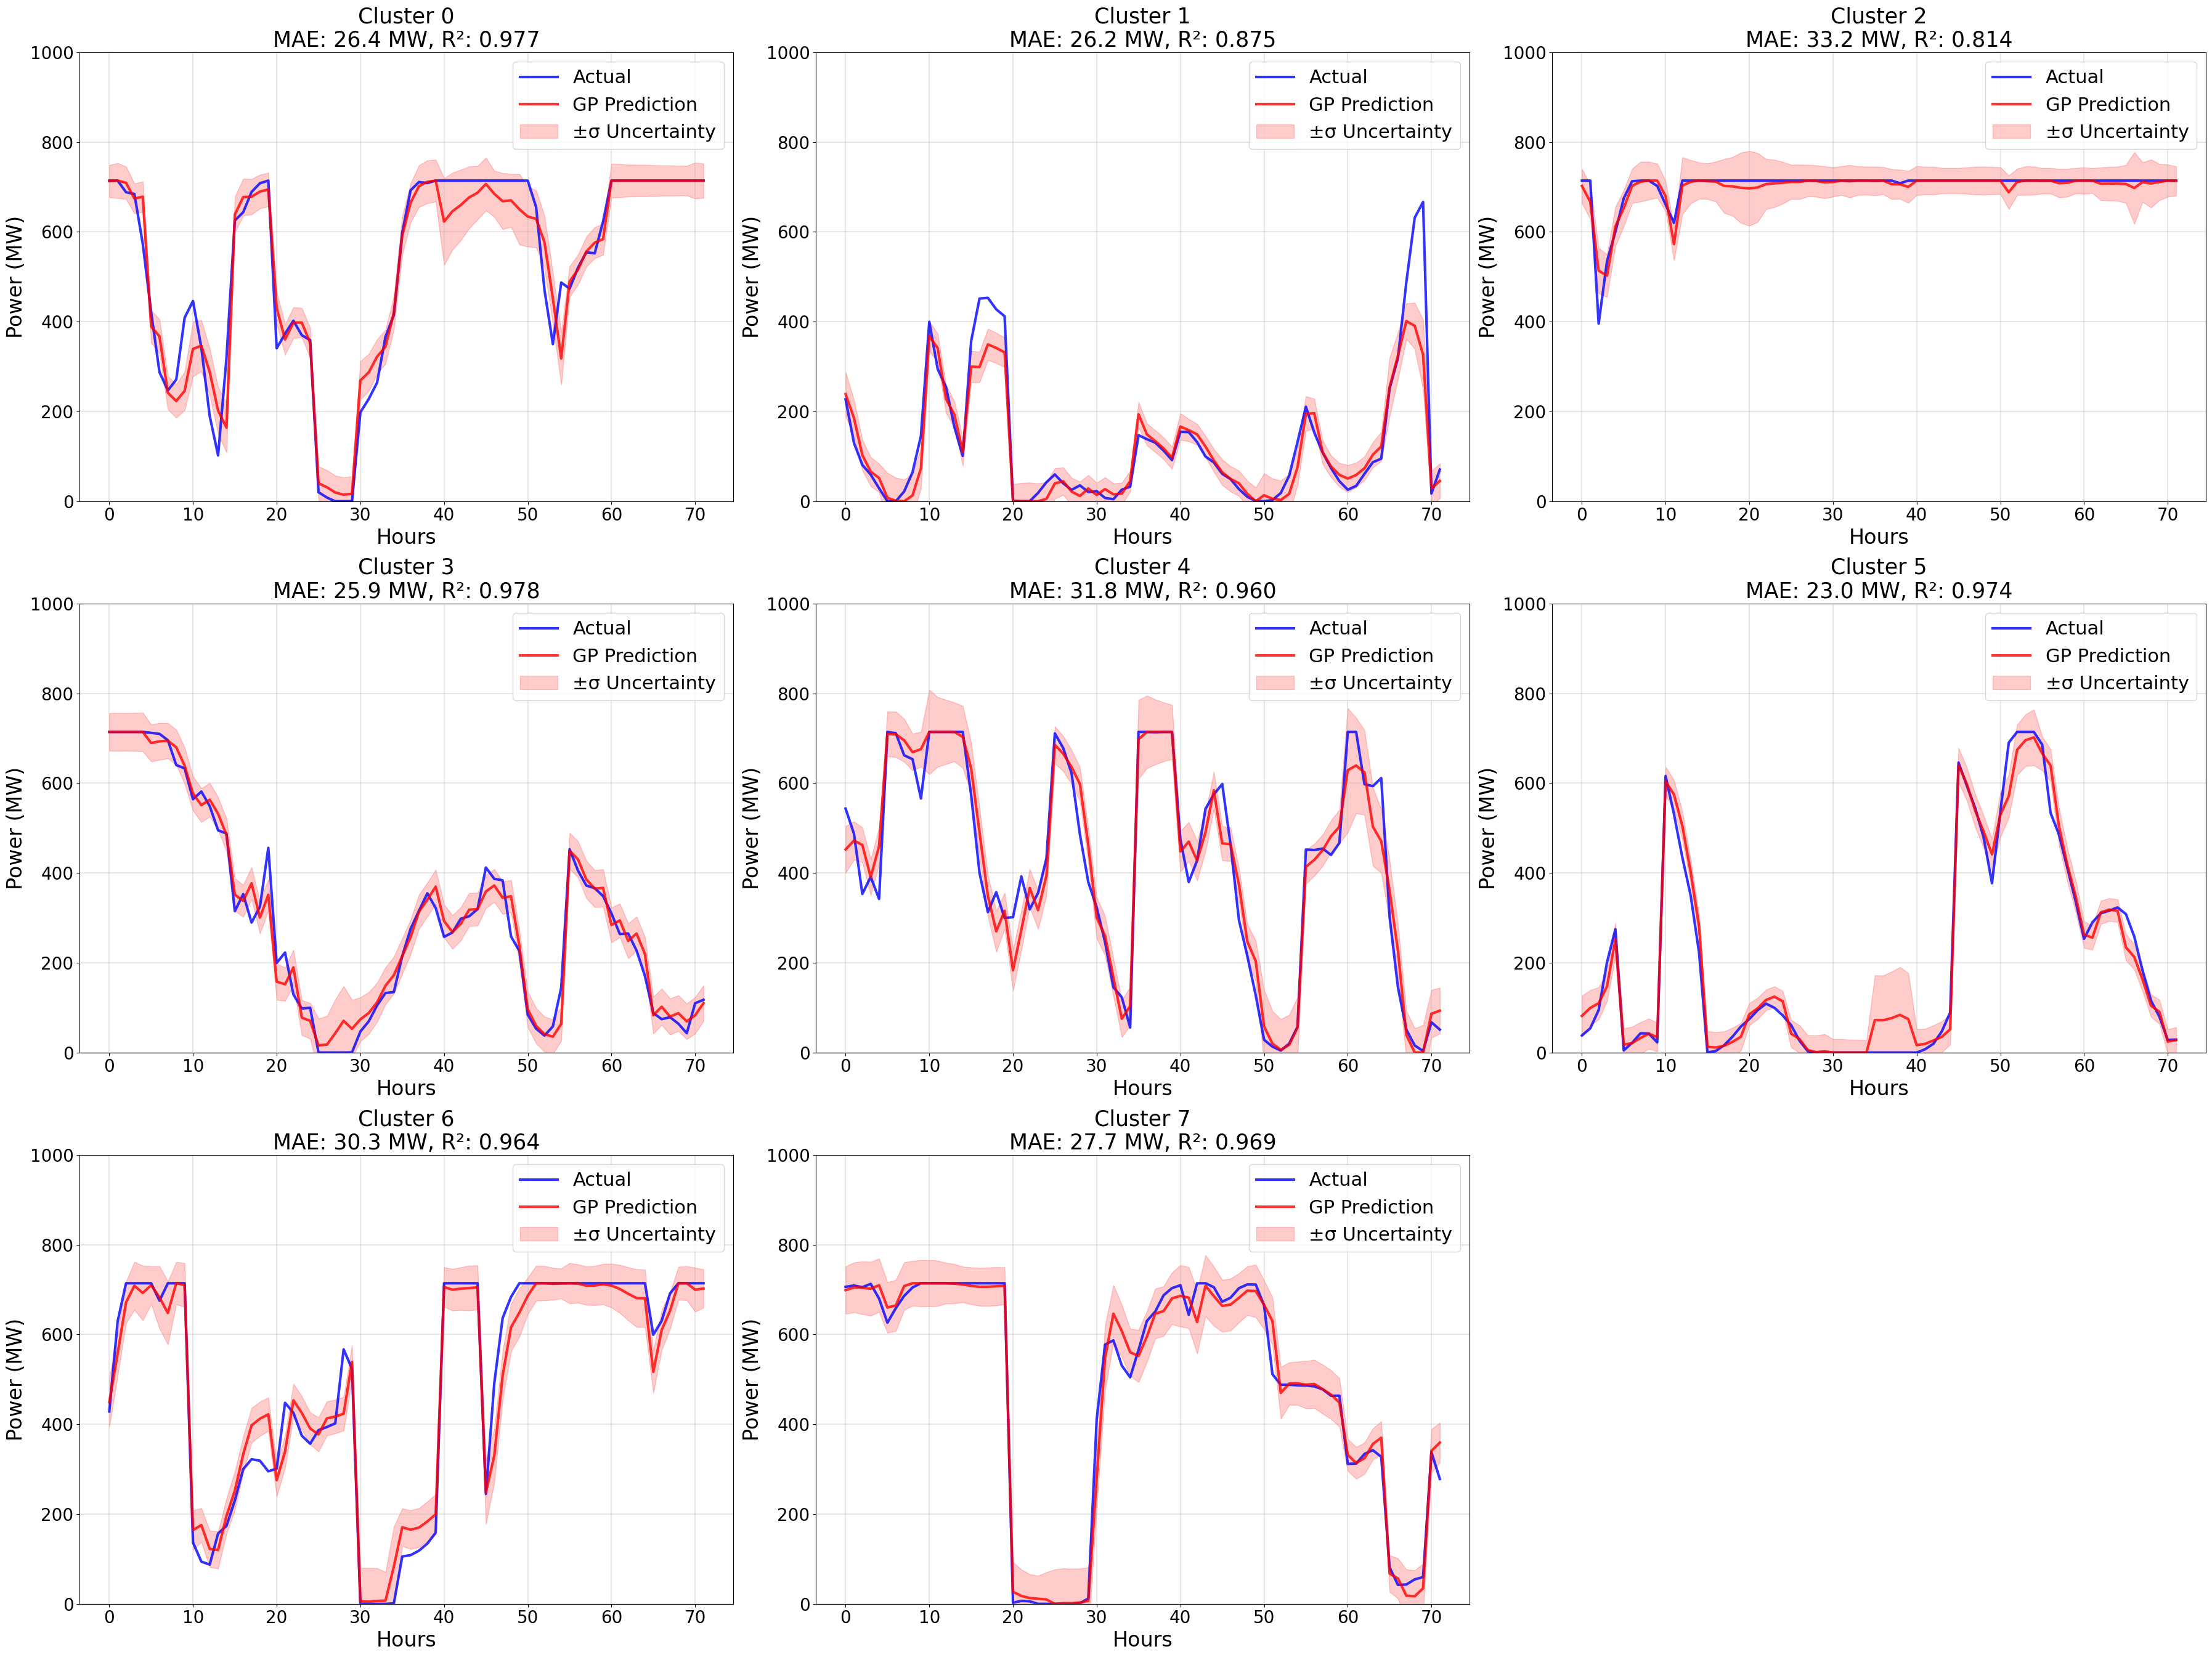


Prediction Plot Summary:
Cluster 0: MAE=26.4 MW, R²=0.977 (2335 test points)
Cluster 1: MAE=26.2 MW, R²=0.875 (1310 test points)
Cluster 2: MAE=33.2 MW, R²=0.814 (1217 test points)
Cluster 3: MAE=25.9 MW, R²=0.978 (1780 test points)
Cluster 4: MAE=31.8 MW, R²=0.960 (1610 test points)
Cluster 5: MAE=23.0 MW, R²=0.974 (1570 test points)
Cluster 6: MAE=30.3 MW, R²=0.964 (2135 test points)
Cluster 7: MAE=27.7 MW, R²=0.969 (1175 test points)

EXPERIMENT: 20% TARGET DATA

GP TRANSFER LEARNING
Configuration: 6h periods, 8 clusters
Target data: 20.0% training

Extracting and Splitting...
  Filtered 'Turn Off' events: Dropped 2 rows
  Extracted: 2918 periods (skipped 1 discontinuous blocks)
  Full: (2918, 18, 6), VAE: (2918, 6, 6)
Timeseries randomly split into 583 train periods and 2335 test periods
Assigning test periods to clusters
  Test latent features Shape: (583, 8)
  Cluster 0: 117 test periods
  Cluster 1: 42 test periods
  Cluster 2: 60 test periods
  Cluster 3: 81 test periods
  Clu

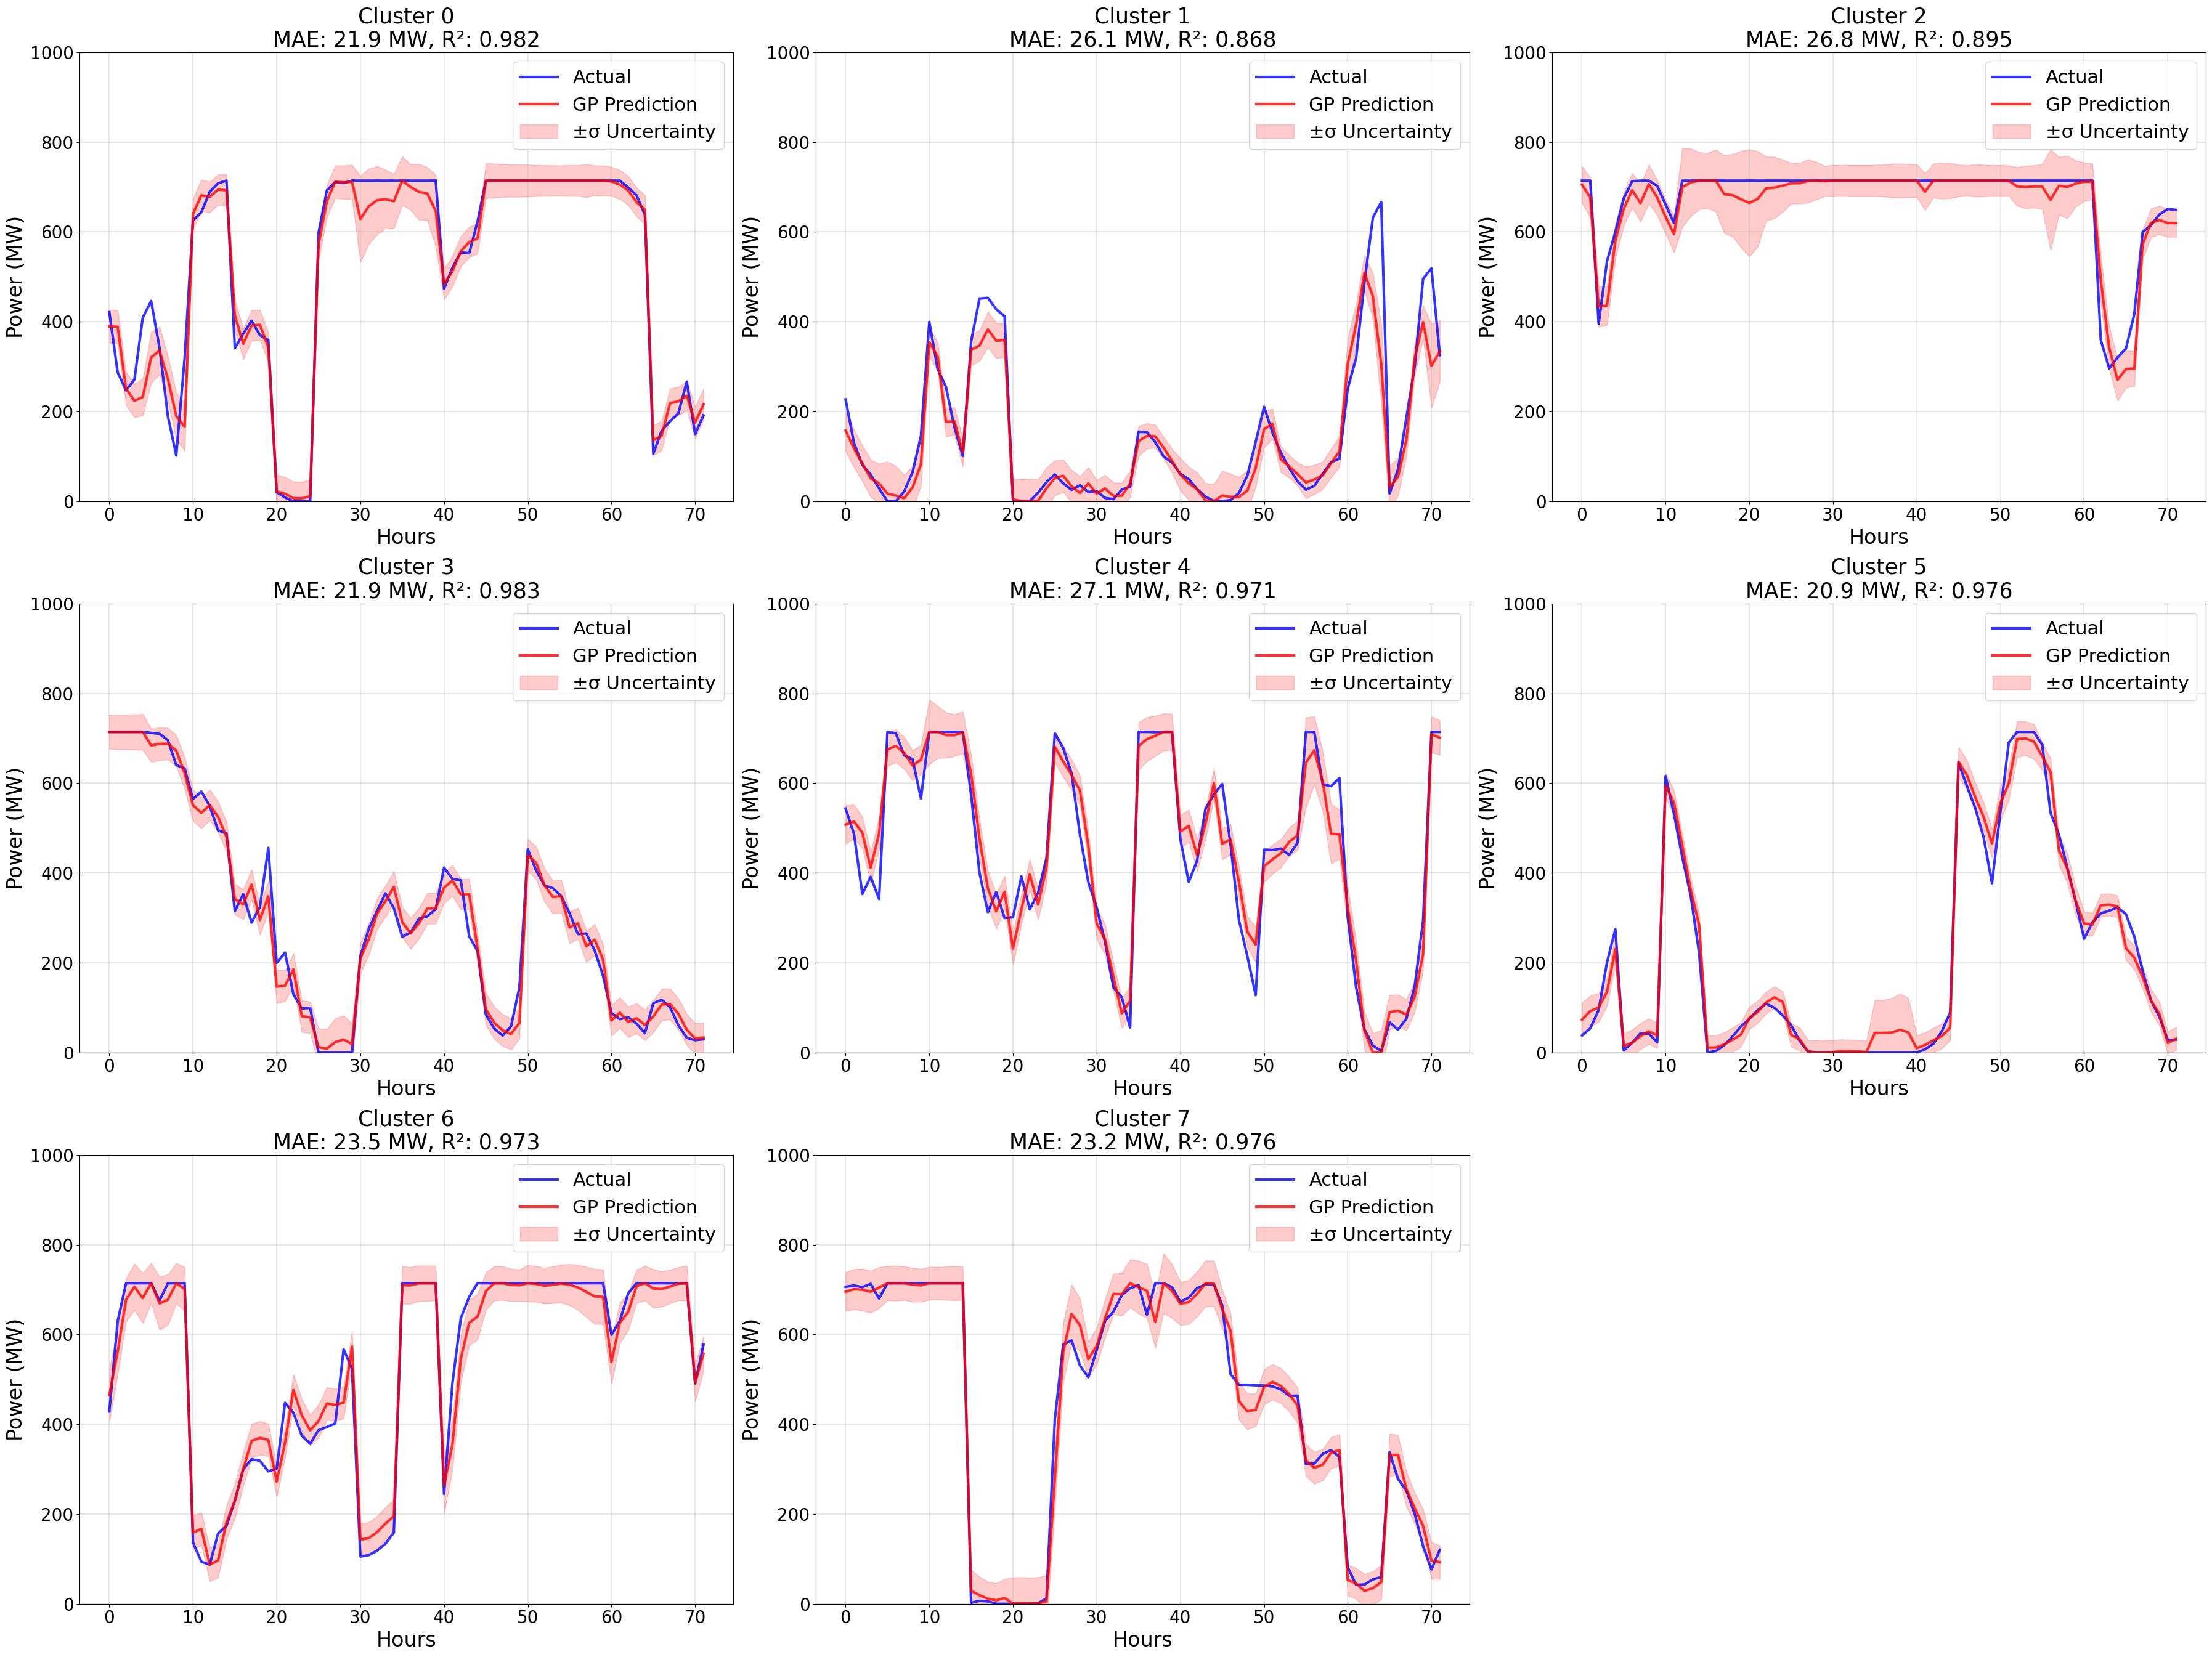


Prediction Plot Summary:
Cluster 0: MAE=21.9 MW, R²=0.982 (2050 test points)
Cluster 1: MAE=26.1 MW, R²=0.868 (1230 test points)
Cluster 2: MAE=26.8 MW, R²=0.895 (1052 test points)
Cluster 3: MAE=21.9 MW, R²=0.983 (1565 test points)
Cluster 4: MAE=27.1 MW, R²=0.971 (1420 test points)
Cluster 5: MAE=20.9 MW, R²=0.976 (1420 test points)
Cluster 6: MAE=23.5 MW, R²=0.973 (1900 test points)
Cluster 7: MAE=23.2 MW, R²=0.976 (1035 test points)

EXPERIMENT: 30% TARGET DATA

GP TRANSFER LEARNING
Configuration: 6h periods, 8 clusters
Target data: 30.0% training

Extracting and Splitting...
  Filtered 'Turn Off' events: Dropped 2 rows
  Extracted: 2918 periods (skipped 1 discontinuous blocks)
  Full: (2918, 18, 6), VAE: (2918, 6, 6)
Timeseries randomly split into 875 train periods and 2043 test periods
Assigning test periods to clusters
  Test latent features Shape: (875, 8)
  Cluster 0: 173 test periods
  Cluster 1: 64 test periods
  Cluster 2: 90 test periods
  Cluster 3: 121 test periods
  Cl

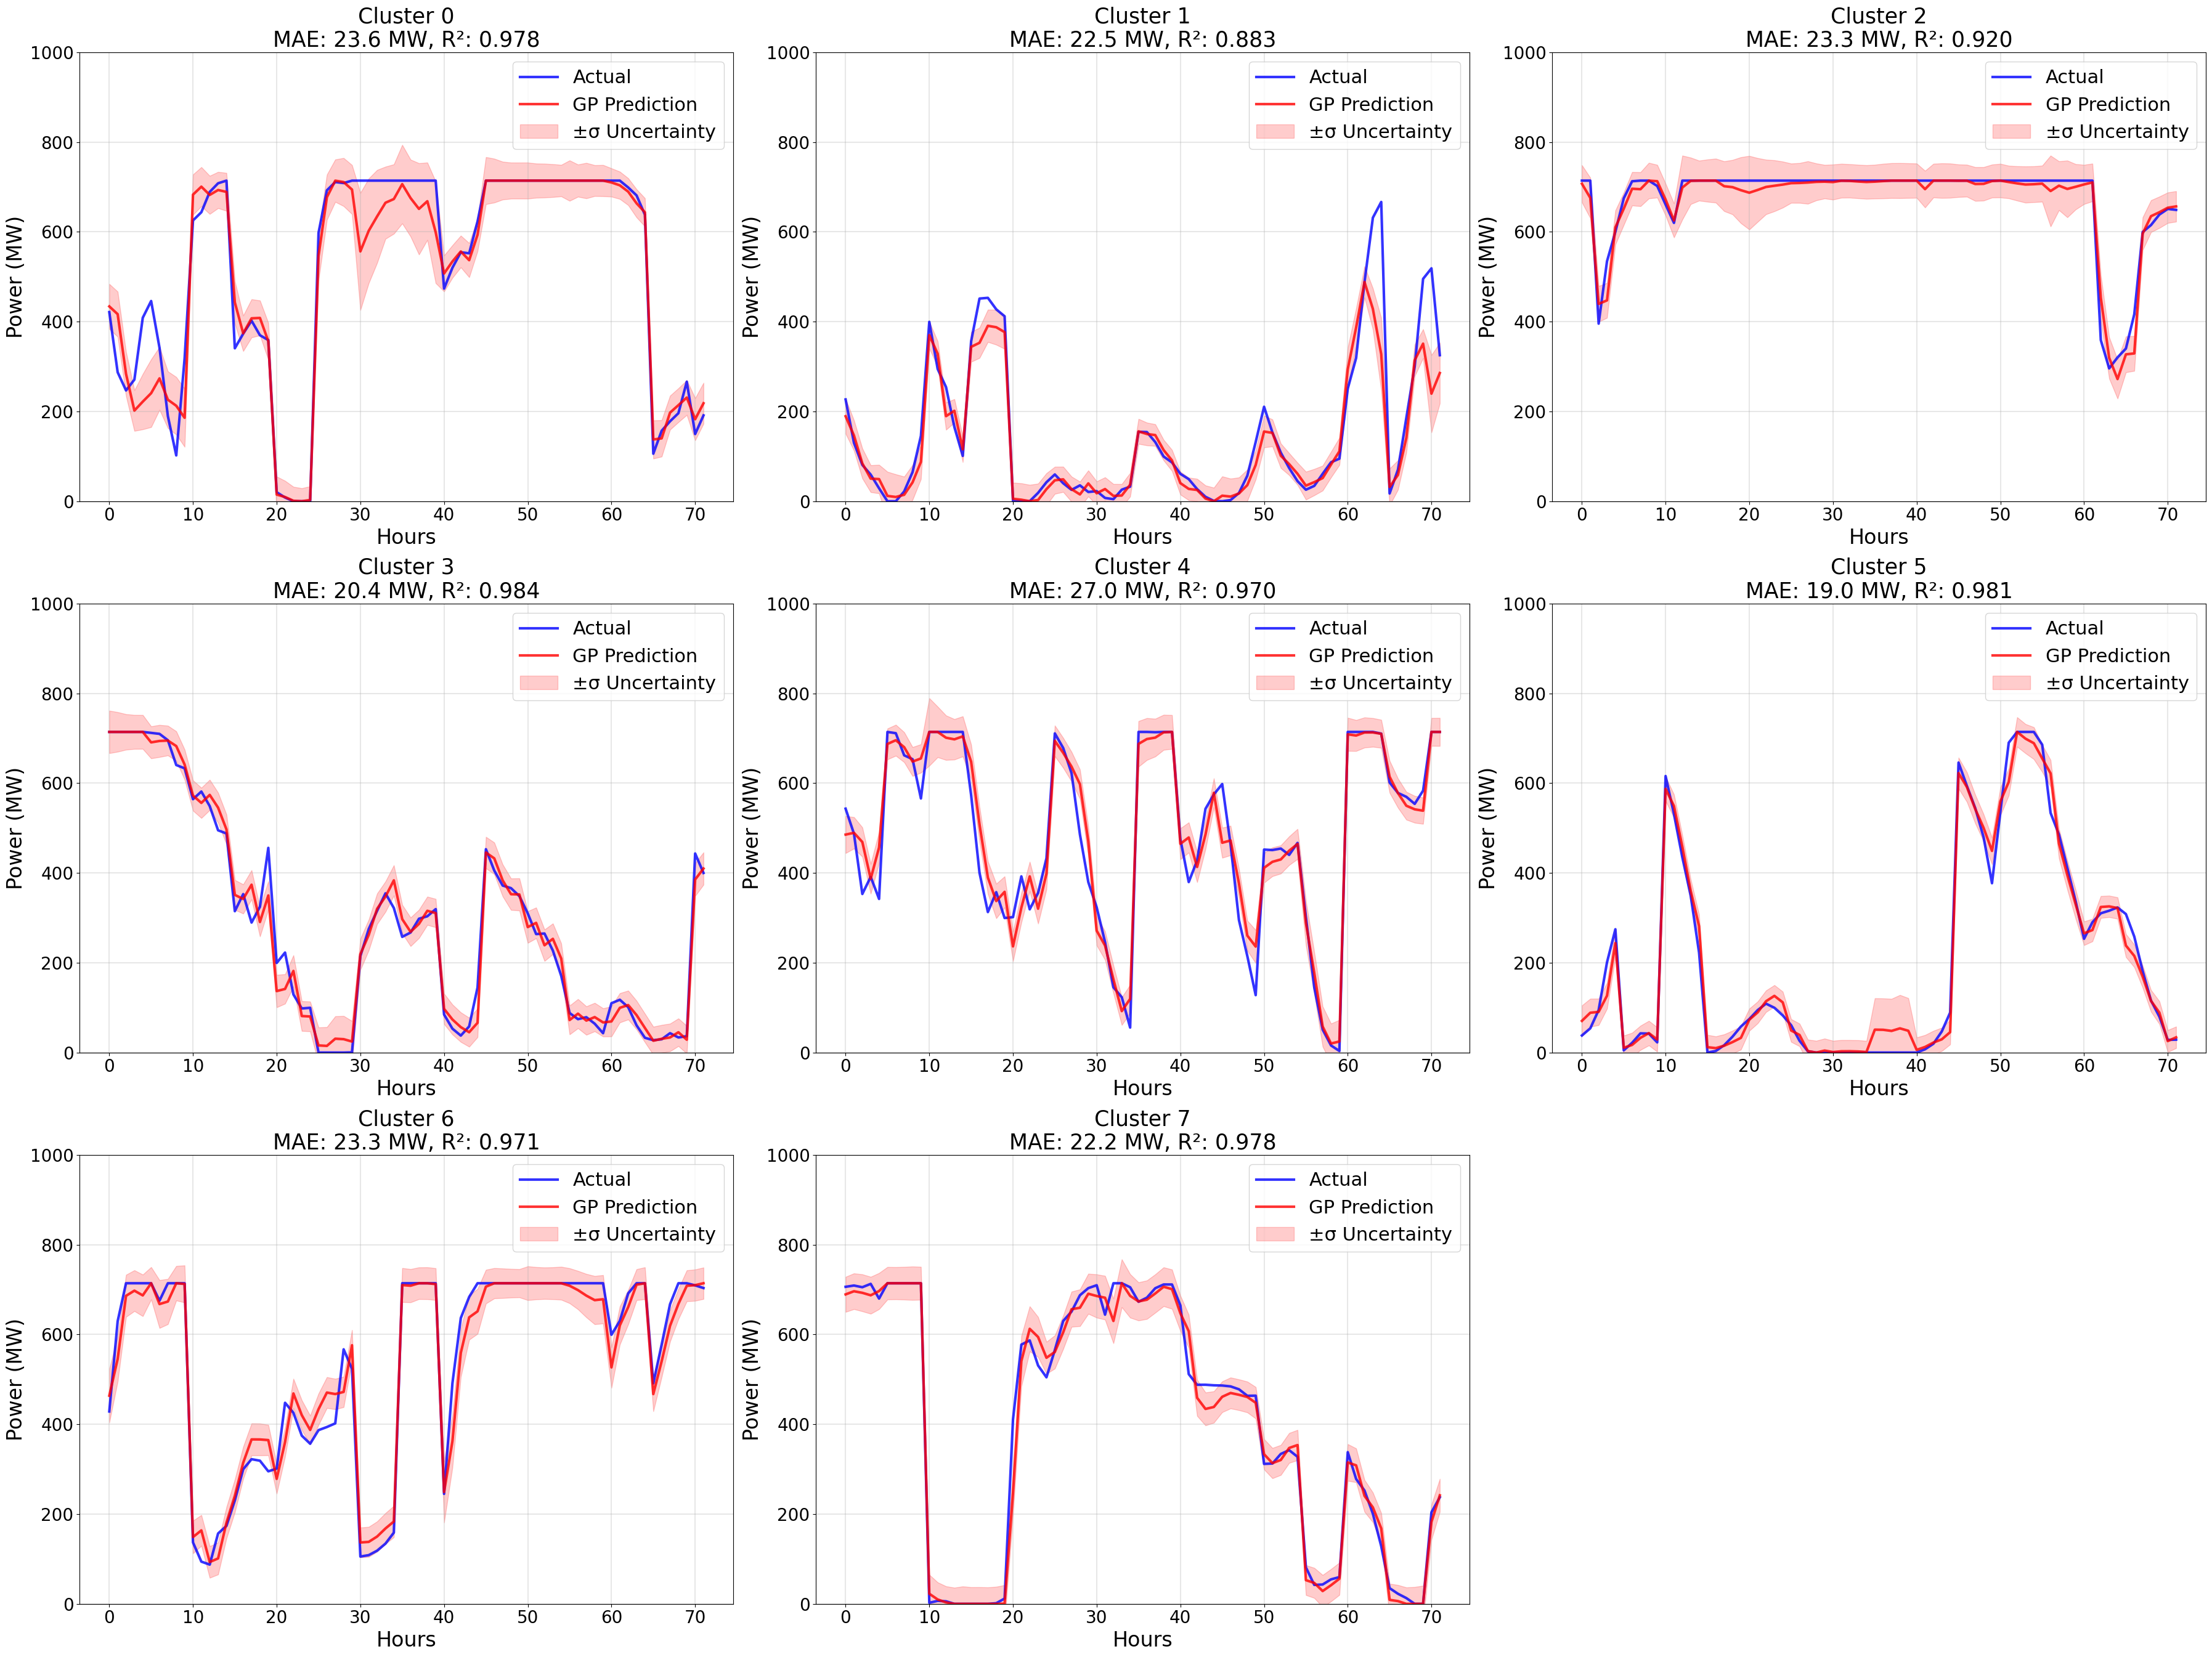


Prediction Plot Summary:
Cluster 0: MAE=23.6 MW, R²=0.978 (1770 test points)
Cluster 1: MAE=22.5 MW, R²=0.883 (1120 test points)
Cluster 2: MAE=23.3 MW, R²=0.920 (902 test points)
Cluster 3: MAE=20.4 MW, R²=0.984 (1365 test points)
Cluster 4: MAE=27.0 MW, R²=0.970 (1260 test points)
Cluster 5: MAE=19.0 MW, R²=0.981 (1210 test points)
Cluster 6: MAE=23.3 MW, R²=0.971 (1675 test points)
Cluster 7: MAE=22.2 MW, R²=0.978 (910 test points)

EXPERIMENT: 40% TARGET DATA

GP TRANSFER LEARNING
Configuration: 6h periods, 8 clusters
Target data: 40.0% training

Extracting and Splitting...
  Filtered 'Turn Off' events: Dropped 2 rows
  Extracted: 2918 periods (skipped 1 discontinuous blocks)
  Full: (2918, 18, 6), VAE: (2918, 6, 6)
Timeseries randomly split into 1167 train periods and 1751 test periods
Assigning test periods to clusters
  Test latent features Shape: (1167, 8)
  Cluster 0: 229 test periods
  Cluster 1: 93 test periods
  Cluster 2: 119 test periods
  Cluster 3: 154 test periods
  C

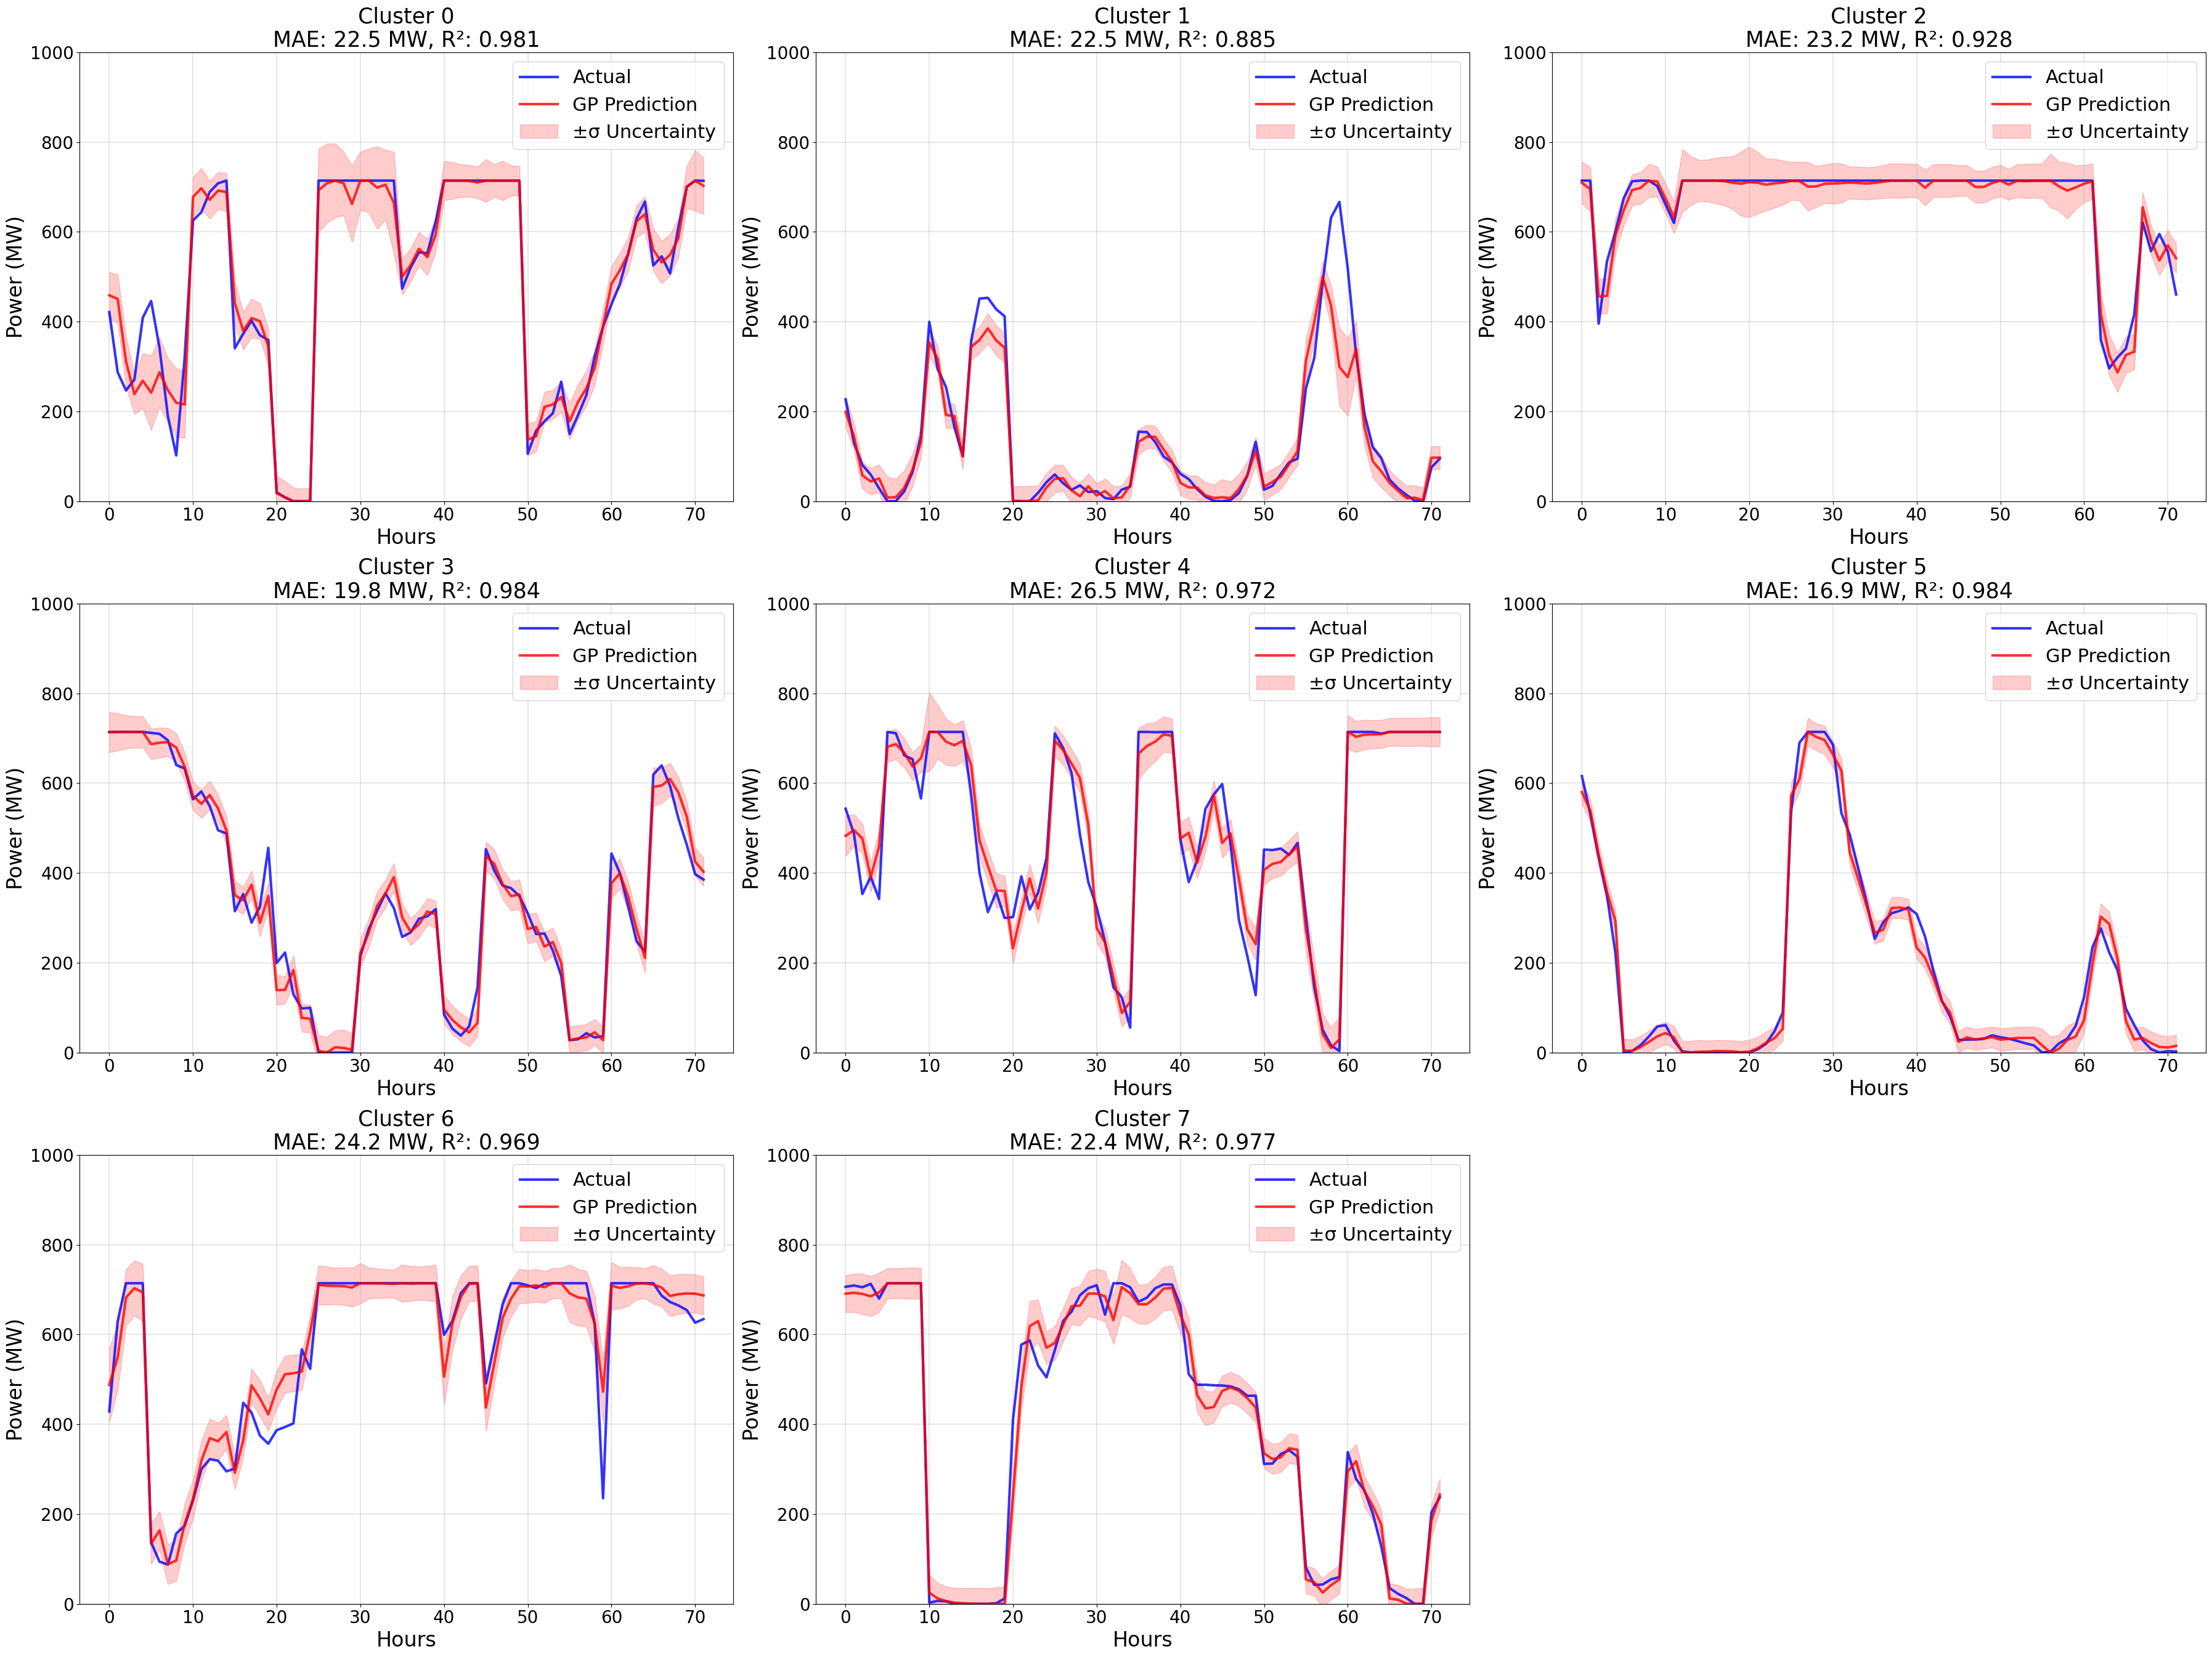


Prediction Plot Summary:
Cluster 0: MAE=22.5 MW, R²=0.981 (1490 test points)
Cluster 1: MAE=22.5 MW, R²=0.885 (975 test points)
Cluster 2: MAE=23.2 MW, R²=0.928 (757 test points)
Cluster 3: MAE=19.8 MW, R²=0.984 (1200 test points)
Cluster 4: MAE=26.5 MW, R²=0.972 (1075 test points)
Cluster 5: MAE=16.9 MW, R²=0.984 (1020 test points)
Cluster 6: MAE=24.2 MW, R²=0.969 (1455 test points)
Cluster 7: MAE=22.4 MW, R²=0.977 (780 test points)

EXPERIMENT: 50% TARGET DATA

GP TRANSFER LEARNING
Configuration: 6h periods, 8 clusters
Target data: 50.0% training

Extracting and Splitting...
  Filtered 'Turn Off' events: Dropped 2 rows
  Extracted: 2918 periods (skipped 1 discontinuous blocks)
  Full: (2918, 18, 6), VAE: (2918, 6, 6)
Timeseries randomly split into 1459 train periods and 1459 test periods
Assigning test periods to clusters
  Test latent features Shape: (1459, 8)
  Cluster 0: 282 test periods
  Cluster 1: 127 test periods
  Cluster 2: 151 test periods
  Cluster 3: 191 test periods
  C

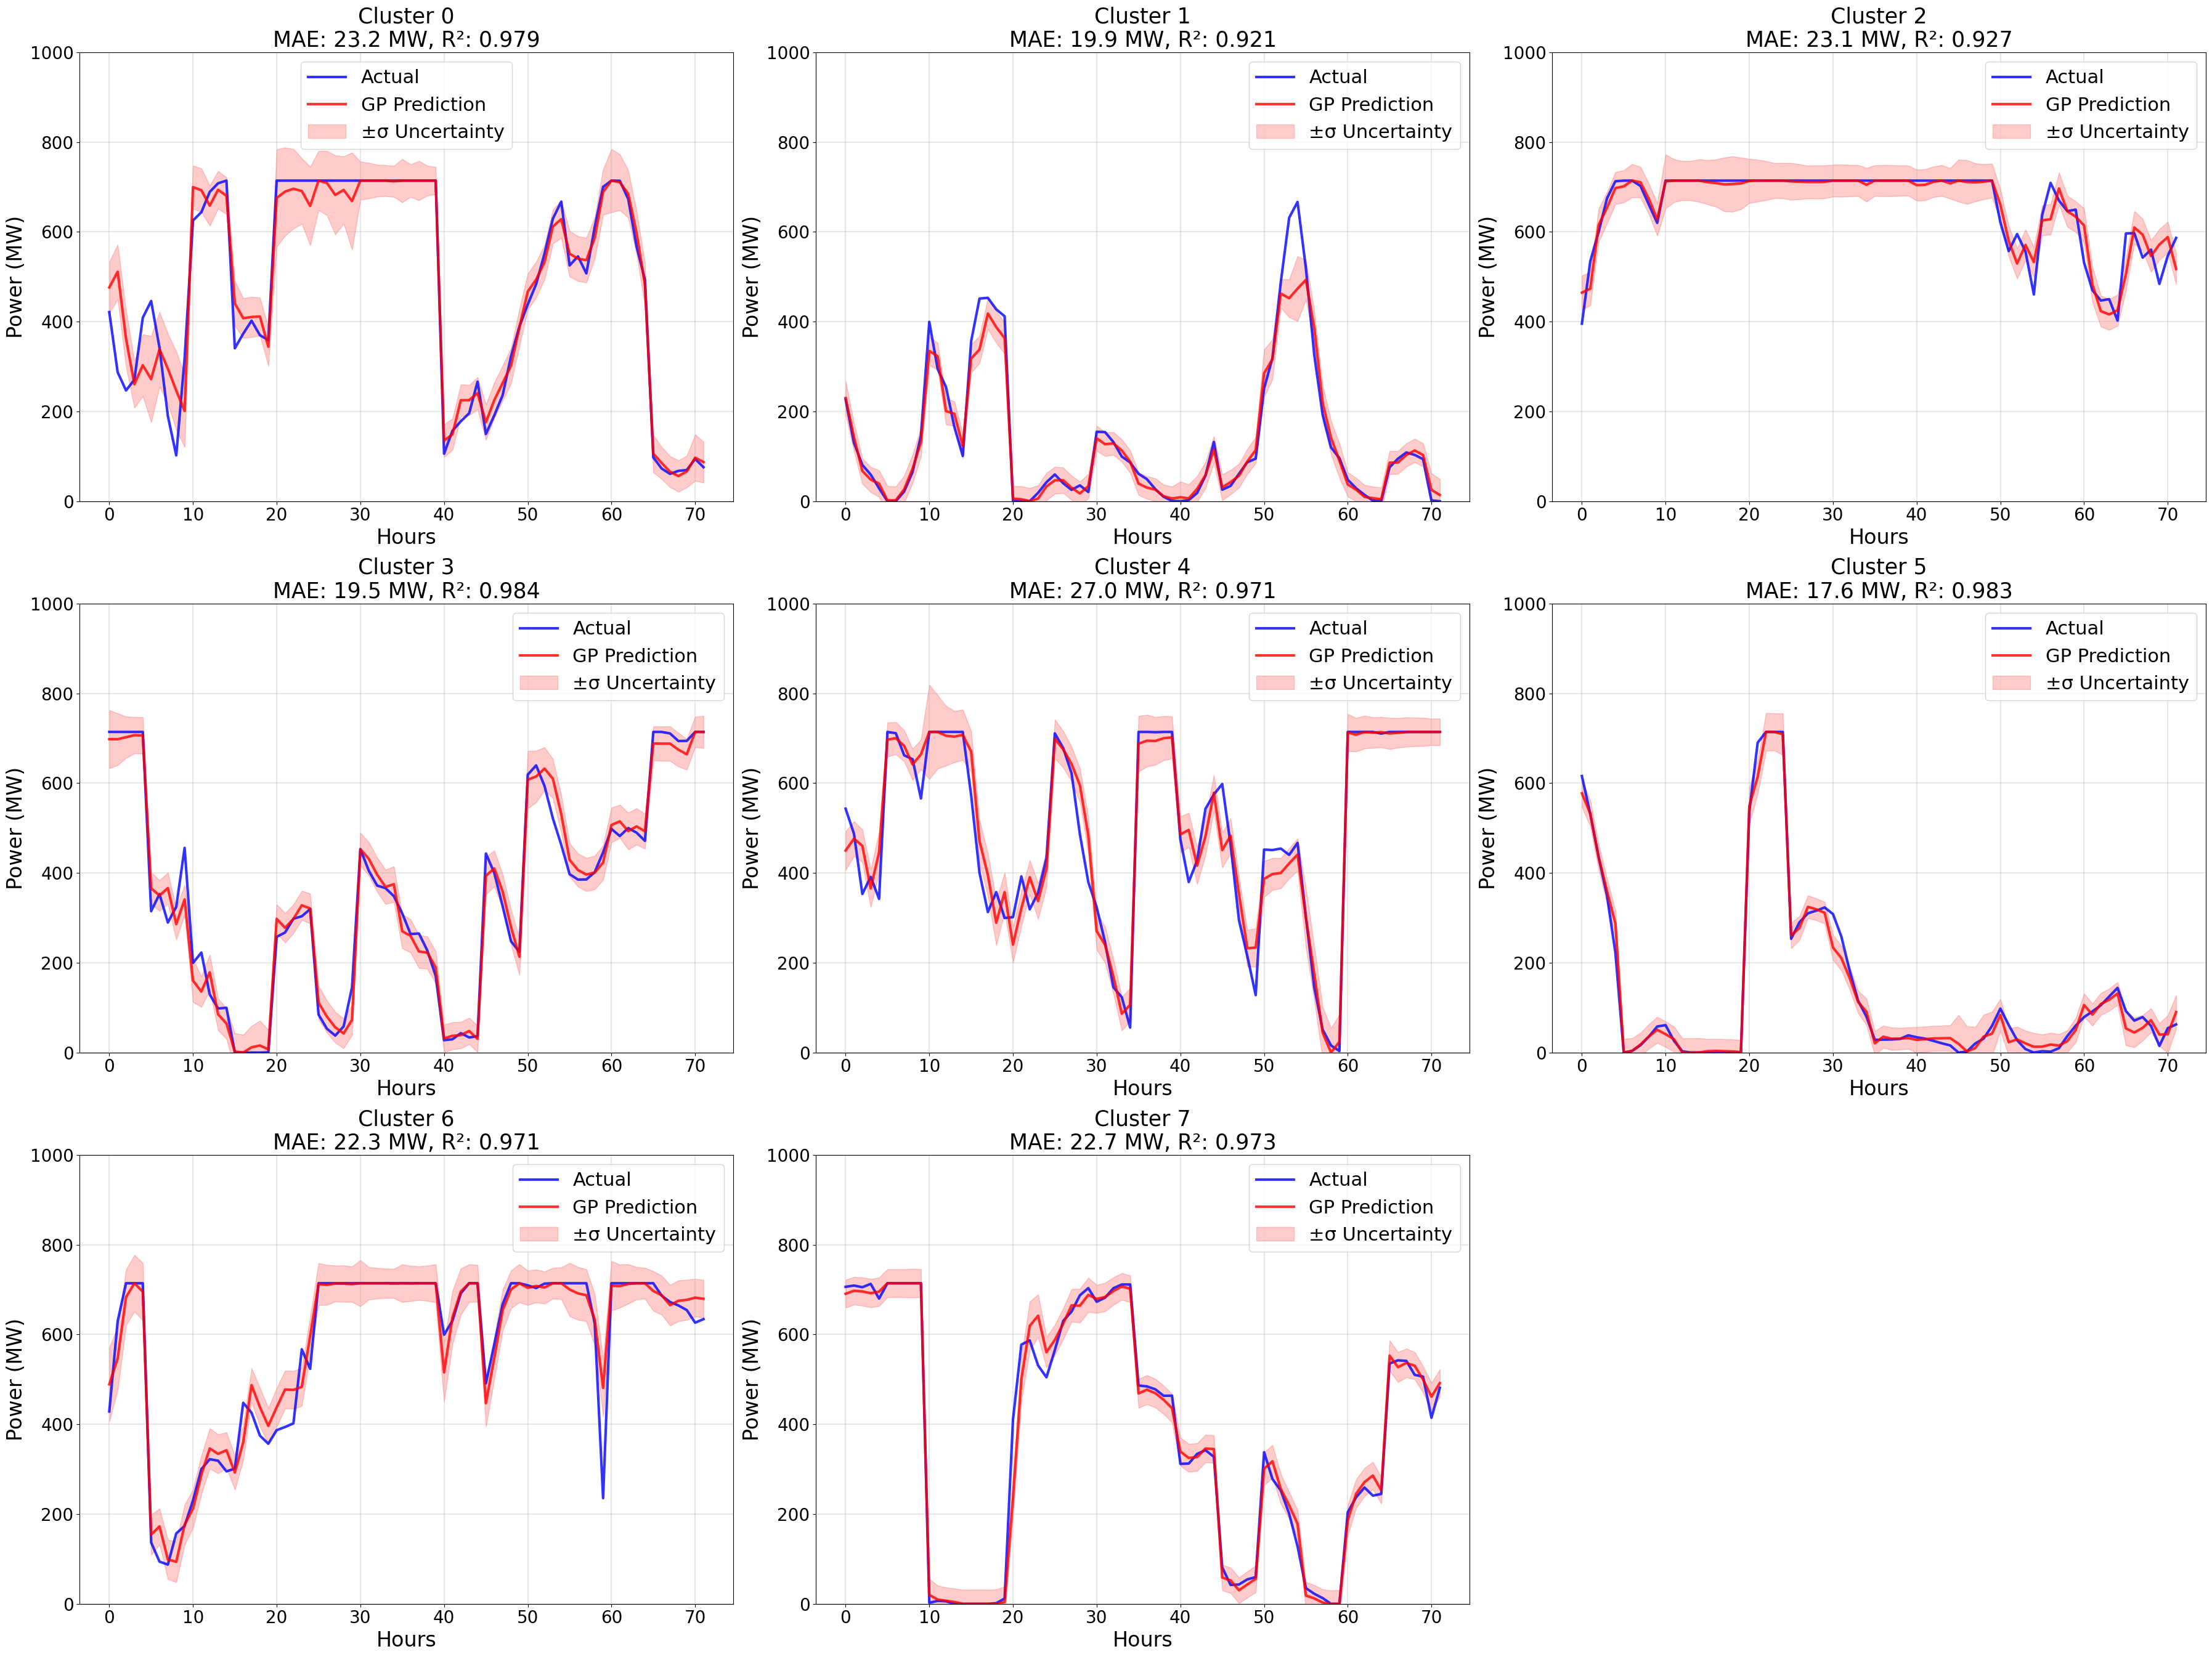


Prediction Plot Summary:
Cluster 0: MAE=23.2 MW, R²=0.979 (1225 test points)
Cluster 1: MAE=19.9 MW, R²=0.921 (805 test points)
Cluster 2: MAE=23.1 MW, R²=0.927 (600 test points)
Cluster 3: MAE=19.5 MW, R²=0.984 (1015 test points)
Cluster 4: MAE=27.0 MW, R²=0.971 (945 test points)
Cluster 5: MAE=17.6 MW, R²=0.983 (825 test points)
Cluster 6: MAE=22.3 MW, R²=0.971 (1245 test points)
Cluster 7: MAE=22.7 MW, R²=0.973 (635 test points)


In [ ]:
fractions = [0.1, 0.2, 0.3, 0.4, 0.5]           
results_by_fraction = {}

for frac in fractions:
    print(f"\n{'='*80}")
    print(f"EXPERIMENT: {frac*100:.0f}% TARGET DATA")
    print(f"{'='*80}\n")

    results = transfer_learning_gp(
        target_df,
        source_results,
        data_fraction=frac,
        gp_dir=fr'...\Seed 84',
        plot_predictions_flag=True,
        random_state=84
    )

Baseline 1: Cluster-specific GPs trained from scratch (No fine-tuning)

In [ ]:
def baseline_no_transfer(target_df, source_results, data_fraction=0.1, 
                          training_iterations=100, random_state=42):
    
    print("="*80)
    
    optimal_config = source_results['optimal_config']
    n_clusters = optimal_config['k_clusters']
    time_period_hours = optimal_config['time_period_hours']
    source_vae = optimal_config['vae']
    source_train_latent = optimal_config['train_latent']
    source_train_labels = optimal_config['train_cluster_labels']
    
    source_scalers_vae = optimal_config['scalers_vae']
    source_log_transforms_vae = optimal_config.get('log_transforms_vae', {})
    source_scalers_full = optimal_config['scalers_full']
    source_log_transforms_full = optimal_config.get('log_transforms_full', {})
    
    source_vae.eval()
    
    print(f"Configuration: {time_period_hours}h periods, {n_clusters} clusters")
    print(f"Target data: {data_fraction*100:.1f}% for training, {(1-data_fraction)*100:.1f}% for testing")
    print(f"Random seed: {random_state}")
    
    # DATA PREPARATION
    print("\n Extracting and Splitting...")
    timeseries_matrix_full_t, timeseries_matrix_vae_t, period_info_t = extract_timeseries(target_df, time_period_hours)
    
    test_ratio = 1.0 - data_fraction
    split_data_vae = split_timeperiods(timeseries_matrix_vae_t, period_info_t, test_ratio=test_ratio, random_state=random_state)
    
    train_indices = split_data_vae['train_indices']
    test_indices = split_data_vae['test_indices']
    train_period_info = split_data_vae['train_period_info']
    test_period_info = split_data_vae['test_period_info']
    
    train_timeseries_full_t = timeseries_matrix_full_t[train_indices]
    test_timeseries_full_t = timeseries_matrix_full_t[test_indices]
    train_timeseries_vae_t = split_data_vae['train_timeseries']
    test_timeseries_vae_t = split_data_vae['test_timeseries']
    
    # Normalisation
    vae_feature_names = ['Windspeed', 'fsr', 'u100', 'v100', 'wind_dir_sin', 'wind_dir_cos']
    train_normalised_vae_t = np.zeros_like(train_timeseries_vae_t, dtype=np.float32)
    test_normalised_vae_t = np.zeros_like(test_timeseries_vae_t, dtype=np.float32)

    for ch in range(train_timeseries_vae_t.shape[1]):
        channel_name = vae_feature_names[ch] if ch < len(vae_feature_names) else f'Channel_{ch}'
        if any(cyc in channel_name for cyc in ['sin', 'cos']):
            train_normalised_vae_t[:, ch, :] = train_timeseries_vae_t[:, ch, :]
            test_normalised_vae_t[:, ch, :] = test_timeseries_vae_t[:, ch, :]
            continue
        if channel_name in source_scalers_vae: 
            scaler_vae = source_scalers_vae[channel_name]   
            train_flat = train_timeseries_vae_t[:, ch, :].flatten()
            test_flat = test_timeseries_vae_t[:, ch, :].flatten()
            if source_log_transforms_vae.get(channel_name, False):
                train_flat = np.log(train_flat + 1e-10)
                test_flat = np.log(test_flat + 1e-10)
            train_scaled = scaler_vae.transform(train_flat.reshape(-1, 1)).flatten()
            test_scaled = scaler_vae.transform(test_flat.reshape(-1, 1)).flatten()
            train_normalised_vae_t[:, ch, :] = train_scaled.reshape(train_timeseries_vae_t.shape[0], -1)
            test_normalised_vae_t[:, ch, :] = test_scaled.reshape(test_timeseries_vae_t.shape[0], -1)
        else:
             train_normalised_vae_t[:, ch, :] = train_timeseries_vae_t[:, ch, :]
             test_normalised_vae_t[:, ch, :] = test_timeseries_vae_t[:, ch, :]

    target_power_scaler = MinMaxScaler(feature_range=(-1, 1))
    raw_train_power = train_timeseries_full_t[:, 0, :].flatten().reshape(-1, 1)
    target_power_scaler.fit(raw_train_power)

    full_feature_names = [
        'Power', 'Windspeed', 'fsr', 'u100', 'v100',
        'Power_t-1', 'Power_t-2', 'Power_t-3',
        'Windspeed_t-1', 'Windspeed_t-2', 'Windspeed_t-3',
        'hour_sin', 'hour_cos', 'wind_dir_sin', 'wind_dir_cos',
        'month_sin', 'month_cos'
    ]

    train_normalised_full_t = np.zeros_like(train_timeseries_full_t, dtype=np.float32)
    test_normalised_full_t = np.zeros_like(test_timeseries_full_t, dtype=np.float32)

    for ch in range(train_timeseries_full_t.shape[1]):
        channel_name = full_feature_names[ch] if ch < len(full_feature_names) else f'Channel_{ch}'
        if any(cyc in channel_name for cyc in ['sin', 'cos']):
            train_normalised_full_t[:, ch, :] = train_timeseries_full_t[:, ch, :]
            test_normalised_full_t[:, ch, :] = test_timeseries_full_t[:, ch, :]
        elif 'Power' in channel_name:
            scaler = target_power_scaler
            train_flat = train_timeseries_full_t[:, ch, :].flatten()
            test_flat = test_timeseries_full_t[:, ch, :].flatten()
            train_scaled = scaler.transform(train_flat.reshape(-1, 1)).flatten()
            test_scaled = scaler.transform(test_flat.reshape(-1, 1)).flatten()
            train_normalised_full_t[:, ch, :] = train_scaled.reshape(train_timeseries_full_t.shape[0], -1)
            test_normalised_full_t[:, ch, :] = test_scaled.reshape(test_timeseries_full_t.shape[0], -1)
        elif channel_name in source_scalers_full:
            scaler = source_scalers_full[channel_name]
            train_flat = train_timeseries_full_t[:, ch, :].flatten()
            test_flat = test_timeseries_full_t[:, ch, :].flatten()
            if source_log_transforms_full.get(channel_name, False):
                train_flat = np.log(train_flat + 1e-10)
                test_flat = np.log(test_flat + 1e-10)
            train_scaled = scaler.transform(train_flat.reshape(-1, 1)).flatten()
            test_scaled = scaler.transform(test_flat.reshape(-1, 1)).flatten()
            train_normalised_full_t[:, ch, :] = train_scaled.reshape(train_timeseries_full_t.shape[0], -1)
            test_normalised_full_t[:, ch, :] = test_scaled.reshape(test_timeseries_full_t.shape[0], -1)
        else:
             train_normalised_full_t[:, ch, :] = train_timeseries_full_t[:, ch, :]
             test_normalised_full_t[:, ch, :] = test_timeseries_full_t[:, ch, :]

    train_latent_matrix_t = extract_vae_features(source_vae, train_normalised_vae_t, device='cpu')
    test_latent_matrix_t = extract_vae_features(source_vae, test_normalised_vae_t, device='cpu')
    
    train_cluster_labels_t = assign_test_clusters(source_train_latent, train_latent_matrix_t, source_train_labels)
    test_cluster_labels_t = assign_test_clusters(source_train_latent, test_latent_matrix_t, source_train_labels)
    all_source_clusters = sorted(np.unique(source_train_labels))
    
    train_cluster_dataset = create_cluster_forecasting_datasets(
        train_latent_matrix_t, train_normalised_full_t, train_cluster_labels_t,
        period_indices=np.arange(len(train_latent_matrix_t)),
        period_info=train_period_info,
        forecast_horizon=1
    )
    test_cluster_dataset = create_cluster_forecasting_datasets(
        test_latent_matrix_t, test_normalised_full_t, test_cluster_labels_t,
        period_indices=np.arange(len(test_latent_matrix_t)),
        period_info=test_period_info,
        forecast_horizon=1
    )
    
    def clean_dataset(dataset_dict):
        keys_to_remove = []
        for k in list(dataset_dict.keys()):
            X, y = dataset_dict[k]['X'], dataset_dict[k]['y']
            mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
            dataset_dict[k]['X'] = X[mask]
            dataset_dict[k]['y'] = y[mask]
            if len(dataset_dict[k]['X']) == 0:
                keys_to_remove.append(k)
        for k in keys_to_remove:
            del dataset_dict[k]
    clean_dataset(train_cluster_dataset)
    clean_dataset(test_cluster_dataset)

    # TRAINING FROM SCRATCH
    
    print("\nStep 7: Training New GP models from Scratch...")
    print(f"  Training iterations: {training_iterations}")
    
    cluster_models = {}
    device = 'cpu'
    
    for cluster_id in all_source_clusters:
        if cluster_id not in train_cluster_dataset or cluster_id not in test_cluster_dataset:
            continue
        
        train_data = train_cluster_dataset[cluster_id]
        test_data = test_cluster_dataset[cluster_id]
        X_train, y_train = train_data['X'], train_data['y']
        X_test, y_test = test_data['X'], test_data['y']
        
        if len(X_train) < 10:
            continue
        
        print(f"\nCluster {cluster_id} ({len(X_train)} samples):", end=" ")
        
        train_x = torch.FloatTensor(X_train).to(device)
        train_y = torch.FloatTensor(y_train).to(device)
        test_x = torch.FloatTensor(X_test).to(device)
        
        # Initialisation
        target_likelihood = GaussianLikelihood(noise_constraint=None).to(device)
        target_model = GPModel(train_x, train_y, target_likelihood).to(device)
        
        target_model.train()
        target_likelihood.train()
        
        optimizer = torch.optim.Adam(target_model.parameters(), lr=0.1)
        mll = ExactMarginalLogLikelihood(target_likelihood, target_model)
        
        for i in range(training_iterations):
            optimizer.zero_grad()
            output = target_model(train_x)
            loss = -mll(output, train_y)
            if torch.isnan(loss) or torch.isinf(loss):
                break
            loss.backward()
            optimizer.step()
        
        target_model.eval()
        target_likelihood.eval()
        
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            predictions = target_likelihood(target_model(test_x))
            y_pred = predictions.mean.cpu().numpy()
            y_std = predictions.stddev.cpu().numpy()
        
        y_test_mw = target_power_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
        y_pred_mw = target_power_scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()
        max_capacity = target_power_scaler.data_max_[0]
        y_pred_mw = np.clip(y_pred_mw, 0, max_capacity)
        
        mw_range = max_capacity - target_power_scaler.data_min_[0]
        feature_range_width = 2.0
        y_std_mw = y_std * (mw_range / feature_range_width)
        
        mae = mean_absolute_error(y_test_mw, y_pred_mw)
        r2 = r2_score(y_test_mw, y_pred_mw)
        rmse = np.sqrt(mean_squared_error(y_test_mw, y_pred_mw))
        
        lpd = gaussian_log_predictive_density(y_test_mw, y_pred_mw, y_std_mw)
        crps = gaussian_crps(y_test_mw, y_pred_mw, y_std_mw)
        picp95 = prediction_interval_coverage(y_test_mw, y_pred_mw, y_std_mw, interval=0.95)

        print(f"MAE: {mae:.1f} MW, R²: {r2:.3f}, LPD: {lpd:.3f}, CRPS: {crps:.3f}, PICP95: {picp95:.3f}")
        
        cluster_models[cluster_id] = {
            'gp': target_model,
            'likelihood': target_likelihood,
            'metrics': {'mae': mae, 'r2': r2, 'rmse': rmse, 'lpd': lpd, 'crps': crps, 'picp95': picp95, 'n_test': len(y_test)},
            'predictions_mw': y_pred_mw,
            'actuals_mw': y_test_mw,
            'uncertainties_mw': y_std_mw
        }
    
    if not cluster_models:
        raise RuntimeError("No GP models were successfully processed")
    
    # Calculate Overall Stats
    maes = [m['metrics']['mae'] for m in cluster_models.values()]
    weights = [m['metrics']['n_test'] for m in cluster_models.values()]
    total = sum(weights)
    w_mae = sum(m * w for m, w in zip(maes, weights)) / total
    
    mae_arr = np.array(maes)
    w_arr = np.array(weights) / total
    mae_std = np.sqrt(np.sum(w_arr * (mae_arr - w_mae)**2))
    
    r2s = [m['metrics']['r2'] for m in cluster_models.values()]
    r2_arr = np.array(r2s)
    w_r2 = np.sum(r2_arr * w_arr)
    r2_std = np.sqrt(np.sum(w_arr * (r2_arr - w_r2)**2))
    
    rmses = [m['metrics']['rmse'] for m in cluster_models.values()]
    lpds = [m['metrics']['lpd'] for m in cluster_models.values()]
    crpss = [m['metrics']['crps'] for m in cluster_models.values()]
    picps = [m['metrics']['picp95'] for m in cluster_models.values()]
    lpds = [m['metrics']['lpd'] for m in cluster_models.values()]
    crpss = [m['metrics']['crps'] for m in cluster_models.values()]
    picps = [m['metrics']['picp95'] for m in cluster_models.values()]
    rmse_arr = np.array(rmses)
    w_rmse = np.sum(rmse_arr * w_arr)
    rmse_std = np.sqrt(np.sum(w_arr * (rmse_arr - w_rmse)**2))

    print(f"\nOVERALL RESULTS:")
    print(f"MAE:  {w_mae:.2f} ± {mae_std:.2f} MW")
    print(f"R²:   {w_r2:.3f} ± {r2_std:.3f}")
    print(f"RMSE: {w_rmse:.2f} ± {rmse_std:.2f} MW")
    
    return {
        'cluster_models': cluster_models,
        'overall_metrics': {
            'mae_mean': w_mae, 'mae_std': mae_std,
            'r2_mean': w_r2, 'r2_std': r2_std,
            'rmse_mean': w_rmse, 'rmse_std': rmse_std
        },
        'data_fraction': data_fraction,
        'random_state': random_state
    }


In [ ]:
fractions = [0.1, 0.2, 0.3, 0.4, 0.5]                   
results_by_fraction = {}

for frac in fractions:
    print(f"\n{'='*80}")
    print(f"EXPERIMENT: {frac*100:.0f}% TARGET DATA")
    print(f"{'='*80}\n")

    results = baseline_no_transfer(
        target_df,
        source_results,
        data_fraction=frac,
        training_iterations=100,
        random_state=84
    )
    results_by_fraction[frac] = results['overall_metrics']



print("\n" + "="*80)
print("SUMMARY ACROSS ALL DATA FRACTIONS")
print("="*80)
for frac in sorted(results_by_fraction.keys()):
    metrics = results_by_fraction[frac]
    print(f"{frac*100:3.0f}%: MAE={metrics['mae_mean']:5.2f}±{metrics['mae_std']:4.2f} MW, "
          f"R²={metrics['r2_mean']:.3f}±{metrics['r2_std']:.3f}")

Baseline 2: Single GP trained per Target farm (No Clustering)

In [ ]:
def baseline_single_gp_per_farm(target_df, source_results, data_fraction=0.1,
                                plot_predictions_flag=False, random_state=42):


    print("=" * 80)

    optimal_config = source_results['optimal_config']
    time_period_hours = optimal_config['time_period_hours']
    source_vae = optimal_config['vae']
    source_scalers_vae = optimal_config['scalers_vae']
    source_log_transforms_vae = optimal_config.get('log_transforms_vae', {})
    source_scalers_full = optimal_config['scalers_full']
    source_log_transforms_full = optimal_config.get('log_transforms_full', {})

    source_vae.eval()

    print(f"Configuration: {time_period_hours}h periods, single model (no clusters)")
    print(f"Target data: {data_fraction*100:.1f}% training")

    # Data preparation 
    print("\nExtracting and splitting...")
    timeseries_matrix_full_t, timeseries_matrix_vae_t, period_info_t = extract_timeseries(target_df, time_period_hours)

    test_ratio = 1.0 - data_fraction
    split_data_vae = split_timeperiods(timeseries_matrix_vae_t, period_info_t, test_ratio=test_ratio, random_state=random_state)

    train_indices = split_data_vae['train_indices']
    train_period_info = split_data_vae['train_period_info']
    test_period_info = split_data_vae['test_period_info']

    train_timeseries_full_t = timeseries_matrix_full_t[train_indices]
    test_timeseries_full_t = timeseries_matrix_full_t[split_data_vae['test_indices']]
    train_timeseries_vae_t = split_data_vae['train_timeseries']
    test_timeseries_vae_t = split_data_vae['test_timeseries']

    vae_feature_names = ['Windspeed', 'fsr', 'u100', 'v100', 'wind_dir_sin', 'wind_dir_cos']
    train_normalised_vae_t = np.zeros_like(train_timeseries_vae_t, dtype=np.float32)
    test_normalised_vae_t = np.zeros_like(test_timeseries_vae_t, dtype=np.float32)

    for ch in range(train_timeseries_vae_t.shape[1]):
        channel_name = vae_feature_names[ch] if ch < len(vae_feature_names) else f'Channel_{ch}'
        if any(cyc in channel_name for cyc in ['sin', 'cos']):
            train_normalised_vae_t[:, ch, :] = train_timeseries_vae_t[:, ch, :]
            test_normalised_vae_t[:, ch, :] = test_timeseries_vae_t[:, ch, :]
            continue
        if channel_name in source_scalers_vae:
            scaler_vae = source_scalers_vae[channel_name]
            train_flat = train_timeseries_vae_t[:, ch, :].flatten()
            test_flat = test_timeseries_vae_t[:, ch, :].flatten()
            if source_log_transforms_vae.get(channel_name, False):
                train_flat = np.log(train_flat + 1e-10)
                test_flat = np.log(test_flat + 1e-10)
            train_normalised_vae_t[:, ch, :] = scaler_vae.transform(train_flat.reshape(-1, 1)).flatten().reshape(train_timeseries_vae_t.shape[0], -1)
            test_normalised_vae_t[:, ch, :] = scaler_vae.transform(test_flat.reshape(-1, 1)).flatten().reshape(test_timeseries_vae_t.shape[0], -1)
        else:
            train_normalised_vae_t[:, ch, :] = train_timeseries_vae_t[:, ch, :]
            test_normalised_vae_t[:, ch, :] = test_timeseries_vae_t[:, ch, :]

    target_power_scaler = MinMaxScaler(feature_range=(-1, 1))
    raw_train_power = train_timeseries_full_t[:, 0, :].flatten().reshape(-1, 1)
    target_power_scaler.fit(raw_train_power)

    full_feature_names = [
        'Power', 'Windspeed', 'fsr', 'u100', 'v100',
        'Power_t-1', 'Power_t-2', 'Power_t-3',
        'Windspeed_t-1', 'Windspeed_t-2', 'Windspeed_t-3',
        'hour_sin', 'hour_cos', 'wind_dir_sin', 'wind_dir_cos',
        'month_sin', 'month_cos'
    ]

    train_normalised_full_t = np.zeros_like(train_timeseries_full_t, dtype=np.float32)
    test_normalised_full_t = np.zeros_like(test_timeseries_full_t, dtype=np.float32)

    for ch in range(train_timeseries_full_t.shape[1]):
        channel_name = full_feature_names[ch] if ch < len(full_feature_names) else f'Channel_{ch}'
        if any(cyc in channel_name for cyc in ['sin', 'cos']):
            train_normalised_full_t[:, ch, :] = train_timeseries_full_t[:, ch, :]
            test_normalised_full_t[:, ch, :] = test_timeseries_full_t[:, ch, :]
        elif 'Power' in channel_name:
            scaler = target_power_scaler
            train_flat = train_timeseries_full_t[:, ch, :].flatten()
            test_flat = test_timeseries_full_t[:, ch, :].flatten()
            train_normalised_full_t[:, ch, :] = scaler.transform(train_flat.reshape(-1, 1)).flatten().reshape(train_timeseries_full_t.shape[0], -1)
            test_normalised_full_t[:, ch, :] = scaler.transform(test_flat.reshape(-1, 1)).flatten().reshape(test_timeseries_full_t.shape[0], -1)
        elif channel_name in source_scalers_full:
            scaler = source_scalers_full[channel_name]
            train_flat = train_timeseries_full_t[:, ch, :].flatten()
            test_flat = test_timeseries_full_t[:, ch, :].flatten()
            if source_log_transforms_full.get(channel_name, False):
                train_flat = np.log(train_flat + 1e-10)
                test_flat = np.log(test_flat + 1e-10)
            train_normalised_full_t[:, ch, :] = scaler.transform(train_flat.reshape(-1, 1)).flatten().reshape(train_timeseries_full_t.shape[0], -1)
            test_normalised_full_t[:, ch, :] = scaler.transform(test_flat.reshape(-1, 1)).flatten().reshape(test_timeseries_full_t.shape[0], -1)
        else:
            train_normalised_full_t[:, ch, :] = train_timeseries_full_t[:, ch, :]
            test_normalised_full_t[:, ch, :] = test_timeseries_full_t[:, ch, :]

    train_latent_matrix_t = extract_vae_features(source_vae, train_normalised_vae_t, device='cpu')
    test_latent_matrix_t = extract_vae_features(source_vae, test_normalised_vae_t, device='cpu')

    # Single "cluster" - all periods assigned to cluster 0 (no weather-pattern clustering)
    train_cluster_labels_t = np.zeros(len(train_latent_matrix_t), dtype=int)
    test_cluster_labels_t = np.zeros(len(test_latent_matrix_t), dtype=int)

    train_cluster_dataset = create_cluster_forecasting_datasets(
        train_latent_matrix_t, train_normalised_full_t, train_cluster_labels_t,
        period_indices=np.arange(len(train_latent_matrix_t)),
        period_info=train_period_info,
        forecast_horizon=1
    )
    test_cluster_dataset = create_cluster_forecasting_datasets(
        test_latent_matrix_t, test_normalised_full_t, test_cluster_labels_t,
        period_indices=np.arange(len(test_latent_matrix_t)),
        period_info=test_period_info,
        forecast_horizon=1
    )

    def clean_dataset(dataset_dict):
        for k in list(dataset_dict.keys()):
            X, y = dataset_dict[k]['X'], dataset_dict[k]['y']
            mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
            dataset_dict[k]['X'] = X[mask]
            dataset_dict[k]['y'] = y[mask]
            if len(dataset_dict[k]['X']) == 0:
                del dataset_dict[k]

    clean_dataset(train_cluster_dataset)
    clean_dataset(test_cluster_dataset)

    if 0 not in train_cluster_dataset or 0 not in test_cluster_dataset:
        print("No valid data after cleaning.")
        return {'overall_metrics': {}, 'data_fraction': data_fraction, 'random_state': random_state}

    X_train = train_cluster_dataset[0]['X']
    y_train = train_cluster_dataset[0]['y']
    X_test = test_cluster_dataset[0]['X']
    y_test = test_cluster_dataset[0]['y']

    if len(X_train) < 10:
        print("Too few training samples.")
        return {'overall_metrics': {}, 'data_fraction': data_fraction, 'random_state': random_state}

    print(f"\nTraining single GP on {len(X_train)} samples, testing on {len(X_test)} samples...")

    device = 'cpu'
    train_x = torch.FloatTensor(X_train).to(device)
    train_y = torch.FloatTensor(y_train).to(device)
    test_x = torch.FloatTensor(X_test).to(device)

    likelihood = GaussianLikelihood(noise_constraint=None).to(device)
    model = GPModel(train_x, train_y, likelihood).to(device)

    model.train()
    likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
    mll = ExactMarginalLogLikelihood(likelihood, model)

    for i in range(100):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()

    model.eval()
    likelihood.eval()

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        predictions = likelihood(model(test_x))
        y_pred = predictions.mean.cpu().numpy()
        y_std = predictions.stddev.cpu().numpy()

    y_test_mw = target_power_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
    y_pred_mw = target_power_scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()
    max_capacity = target_power_scaler.data_max_[0]
    y_pred_mw = np.clip(y_pred_mw, 0, max_capacity)

    mw_range = max_capacity - target_power_scaler.data_min_[0]
    feature_range_width = 2.0
    y_std_mw = y_std * (mw_range / feature_range_width)

    mae = mean_absolute_error(y_test_mw, y_pred_mw)
    r2 = r2_score(y_test_mw, y_pred_mw)
    rmse = np.sqrt(mean_squared_error(y_test_mw, y_pred_mw))
    lpd = gaussian_log_predictive_density(y_test_mw, y_pred_mw, y_std_mw)
    crps = gaussian_crps(y_test_mw, y_pred_mw, y_std_mw)
    picp95 = prediction_interval_coverage(y_test_mw, y_pred_mw, y_std_mw, interval=0.95)

    print(f"\nBASELINE RESULTS:")
    print(f"MAE:   {mae:.2f} MW")
    print(f"R²:    {r2:.3f}")
    print(f"RMSE:  {rmse:.2f} MW")
    print(f"LPD:   {lpd:.3f}")
    print(f"CRPS:  {crps:.3f}")
    print(f"PICP95:{picp95:.3f}")

    overall_metrics = {
        'mae_mean': mae, 'mae_std': 0.0,
        'r2_mean': r2, 'r2_std': 0.0,
        'rmse_mean': rmse, 'rmse_std': 0.0,
        'lpd_mean': lpd, 'lpd_std': 0.0,
        'crps_mean': crps, 'crps_std': 0.0,
        'picp95_mean': picp95, 'picp95_std': 0.0
    }

    return {
        'overall_metrics': overall_metrics,
        'data_fraction': data_fraction,
        'random_state': random_state,
        'predictions_mw': y_pred_mw,
        'actuals_mw': y_test_mw,
    }


In [ ]:
fractions = [0.1, 0.2, 0.3, 0.4, 0.5]                   
results_by_fraction = {}

for frac in fractions:
    print(f"\n{'='*80}")
    print(f"EXPERIMENT: {frac*100:.0f}% TARGET DATA")
    print(f"{'='*80}\n")

    results = baseline_single_gp_per_farm(target_df, source_results, data_fraction=frac, random_state=84)
    
    results_by_fraction[frac] = results['overall_metrics']

Baseline 3: Single NN model per target farm (No clustering)

In [ ]:
def baseline_single_nn_per_farm(target_df, source_results, data_fraction=0.1,
                                random_state=42, epochs=100, batch_size=256, lr=1e-3):

    print("=" * 80)

    optimal_config = source_results['optimal_config']
    time_period_hours = optimal_config['time_period_hours']
    source_vae = optimal_config['vae']
    source_scalers_vae = optimal_config['scalers_vae']
    source_log_transforms_vae = optimal_config.get('log_transforms_vae', {})
    source_scalers_full = optimal_config['scalers_full']
    source_log_transforms_full = optimal_config.get('log_transforms_full', {})

    source_vae.eval()

    print(f"Configuration: {time_period_hours}h periods, single model (no clusters)")
    print(f"Target data: {data_fraction*100:.1f}% training")

    print("\\nExtracting and splitting...")
    timeseries_matrix_full_t, timeseries_matrix_vae_t, period_info_t = extract_timeseries(target_df, time_period_hours)

    test_ratio = 1.0 - data_fraction
    split_data_vae = split_timeperiods(timeseries_matrix_vae_t, period_info_t, test_ratio=test_ratio, random_state=random_state)

    train_indices = split_data_vae['train_indices']
    train_period_info = split_data_vae['train_period_info']
    test_period_info = split_data_vae['test_period_info']

    train_timeseries_full_t = timeseries_matrix_full_t[train_indices]
    test_timeseries_full_t = timeseries_matrix_full_t[split_data_vae['test_indices']]
    train_timeseries_vae_t = split_data_vae['train_timeseries']
    test_timeseries_vae_t = split_data_vae['test_timeseries']

    vae_feature_names = ['Windspeed', 'fsr', 'u100', 'v100', 'wind_dir_sin', 'wind_dir_cos']
    train_normalised_vae_t = np.zeros_like(train_timeseries_vae_t, dtype=np.float32)
    test_normalised_vae_t = np.zeros_like(test_timeseries_vae_t, dtype=np.float32)

    for ch in range(train_timeseries_vae_t.shape[1]):
        channel_name = vae_feature_names[ch] if ch < len(vae_feature_names) else f'Channel_{ch}'
        if any(cyc in channel_name for cyc in ['sin', 'cos']):
            train_normalised_vae_t[:, ch, :] = train_timeseries_vae_t[:, ch, :]
            test_normalised_vae_t[:, ch, :] = test_timeseries_vae_t[:, ch, :]
            continue
        if channel_name in source_scalers_vae:
            scaler_vae = source_scalers_vae[channel_name]
            train_flat = train_timeseries_vae_t[:, ch, :].flatten()
            test_flat = test_timeseries_vae_t[:, ch, :].flatten()
            if source_log_transforms_vae.get(channel_name, False):
                train_flat = np.log(train_flat + 1e-10)
                test_flat = np.log(test_flat + 1e-10)
            train_normalised_vae_t[:, ch, :] = scaler_vae.transform(train_flat.reshape(-1, 1)).flatten().reshape(train_timeseries_vae_t.shape[0], -1)
            test_normalised_vae_t[:, ch, :] = scaler_vae.transform(test_flat.reshape(-1, 1)).flatten().reshape(test_timeseries_vae_t.shape[0], -1)
        else:
            train_normalised_vae_t[:, ch, :] = train_timeseries_vae_t[:, ch, :]
            test_normalised_vae_t[:, ch, :] = test_timeseries_vae_t[:, ch, :]

    target_power_scaler = MinMaxScaler(feature_range=(-1, 1))
    raw_train_power = train_timeseries_full_t[:, 0, :].flatten().reshape(-1, 1)
    target_power_scaler.fit(raw_train_power)

    full_feature_names = [
        'Power', 'Windspeed', 'fsr', 'u100', 'v100',
        'Power_t-1', 'Power_t-2', 'Power_t-3',
        'Windspeed_t-1', 'Windspeed_t-2', 'Windspeed_t-3',
        'hour_sin', 'hour_cos', 'wind_dir_sin', 'wind_dir_cos',
        'month_sin', 'month_cos'
    ]

    train_normalised_full_t = np.zeros_like(train_timeseries_full_t, dtype=np.float32)
    test_normalised_full_t = np.zeros_like(test_timeseries_full_t, dtype=np.float32)

    for ch in range(train_timeseries_full_t.shape[1]):
        channel_name = full_feature_names[ch] if ch < len(full_feature_names) else f'Channel_{ch}'
        if any(cyc in channel_name for cyc in ['sin', 'cos']):
            train_normalised_full_t[:, ch, :] = train_timeseries_full_t[:, ch, :]
            test_normalised_full_t[:, ch, :] = test_timeseries_full_t[:, ch, :]
        elif 'Power' in channel_name:
            scaler = target_power_scaler
            train_flat = train_timeseries_full_t[:, ch, :].flatten()
            test_flat = test_timeseries_full_t[:, ch, :].flatten()
            train_normalised_full_t[:, ch, :] = scaler.transform(train_flat.reshape(-1, 1)).flatten().reshape(train_timeseries_full_t.shape[0], -1)
            test_normalised_full_t[:, ch, :] = scaler.transform(test_flat.reshape(-1, 1)).flatten().reshape(test_timeseries_full_t.shape[0], -1)
        elif channel_name in source_scalers_full:
            scaler = source_scalers_full[channel_name]
            train_flat = train_timeseries_full_t[:, ch, :].flatten()
            test_flat = test_timeseries_full_t[:, ch, :].flatten()
            if source_log_transforms_full.get(channel_name, False):
                train_flat = np.log(train_flat + 1e-10)
                test_flat = np.log(test_flat + 1e-10)
            train_normalised_full_t[:, ch, :] = scaler.transform(train_flat.reshape(-1, 1)).flatten().reshape(train_timeseries_full_t.shape[0], -1)
            test_normalised_full_t[:, ch, :] = scaler.transform(test_flat.reshape(-1, 1)).flatten().reshape(test_timeseries_full_t.shape[0], -1)
        else:
            train_normalised_full_t[:, ch, :] = train_timeseries_full_t[:, ch, :]
            test_normalised_full_t[:, ch, :] = test_timeseries_full_t[:, ch, :]

    train_latent_matrix_t = extract_vae_features(source_vae, train_normalised_vae_t, device='cpu')
    test_latent_matrix_t = extract_vae_features(source_vae, test_normalised_vae_t, device='cpu')

    train_cluster_labels_t = np.zeros(len(train_latent_matrix_t), dtype=int)
    test_cluster_labels_t = np.zeros(len(test_latent_matrix_t), dtype=int)

    train_cluster_dataset = create_cluster_forecasting_datasets(
        train_latent_matrix_t, train_normalised_full_t, train_cluster_labels_t,
        period_indices=np.arange(len(train_latent_matrix_t)),
        period_info=train_period_info,
        forecast_horizon=1
    )
    test_cluster_dataset = create_cluster_forecasting_datasets(
        test_latent_matrix_t, test_normalised_full_t, test_cluster_labels_t,
        period_indices=np.arange(len(test_latent_matrix_t)),
        period_info=test_period_info,
        forecast_horizon=1
    )

    def clean_dataset(dataset_dict):
        for k in list(dataset_dict.keys()):
            X, y = dataset_dict[k]['X'], dataset_dict[k]['y']
            mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
            dataset_dict[k]['X'] = X[mask]
            dataset_dict[k]['y'] = y[mask]
            if len(dataset_dict[k]['X']) == 0:
                del dataset_dict[k]

    clean_dataset(train_cluster_dataset)
    clean_dataset(test_cluster_dataset)

    if 0 not in train_cluster_dataset or 0 not in test_cluster_dataset:
        print("No valid data after cleaning.")
        return {'overall_metrics': {}, 'data_fraction': data_fraction, 'random_state': random_state}

    X_train = train_cluster_dataset[0]['X'].astype(np.float32)
    y_train = train_cluster_dataset[0]['y'].astype(np.float32)
    X_test = test_cluster_dataset[0]['X'].astype(np.float32)
    y_test = test_cluster_dataset[0]['y'].astype(np.float32)

    if len(X_train) < 10:
        print("Too few training samples.")
        return {'overall_metrics': {}, 'data_fraction': data_fraction, 'random_state': random_state}

    print(f"\\nTraining single NN on {len(X_train)} samples, testing on {len(X_test)} samples...")

    class SingleFarmNN(nn.Module):

        def __init__(self, input_dim, dropout=0.15):
            super().__init__()
            hidden = [256, 256, 192, 128, 96, 64]
            layers = []
            d = input_dim
            for h in hidden:
                layers.extend([
                    nn.Linear(d, h),
                    nn.LayerNorm(h),
                    nn.GELU(),
                    nn.Dropout(dropout),
                ])
                d = h
            layers.extend([nn.Linear(d, 32), nn.GELU(), nn.Linear(32, 1)])
            self.net = nn.Sequential(*layers)

        def forward(self, x):
            return self.net(x).squeeze(-1)

    device = 'cpu'
    model = SingleFarmNN(X_train.shape[1], dropout=0.15).to(device)

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)

    dataset = torch.utils.data.TensorDataset(X_train_t, y_train_t)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)

        if (epoch + 1) % 25 == 0:
            print(f"  Epoch {epoch+1}/{epochs} - train MSE: {epoch_loss / len(dataset):.5f}")

    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_t.to(device)).cpu().numpy()

    y_test_mw = target_power_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
    y_pred_mw = target_power_scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()
    max_capacity = target_power_scaler.data_max_[0]
    y_pred_mw = np.clip(y_pred_mw, 0, max_capacity)

    mae = mean_absolute_error(y_test_mw, y_pred_mw)
    r2 = r2_score(y_test_mw, y_pred_mw)
    rmse = np.sqrt(mean_squared_error(y_test_mw, y_pred_mw))

    print(f"\\nNN BASELINE RESULTS:")
    print(f"MAE:  {mae:.2f} MW")
    print(f"R²:   {r2:.3f}")
    print(f"RMSE: {rmse:.2f} MW")

    overall_metrics = {
        'mae_mean': mae, 'mae_std': 0.0,
        'r2_mean': r2, 'r2_std': 0.0,
        'rmse_mean': rmse, 'rmse_std': 0.0
    }

    return {
        'overall_metrics': overall_metrics,
        'data_fraction': data_fraction,
        'random_state': random_state,
        'predictions_mw': y_pred_mw,
        'actuals_mw': y_test_mw,
    }


In [ ]:
fractions = [0.1, 0.2, 0.3, 0.4, 0.5]                   
results_by_fraction = {}

for frac in fractions:
    print(f"\n{'='*80}")
    print(f"EXPERIMENT: {frac*100:.0f}% TARGET DATA")
    print(f"{'='*80}\n")

    results = baseline_single_nn_per_farm(target_df, source_results, data_fraction=frac, random_state=84)
    
    results_by_fraction[frac] = results['overall_metrics']